In [1]:
import os
import sys
sdk_install_path = r"C:\Program Files\HOLOEYE Photonics\SLM Display SDK (Python) v4.1.0"
python_api_path = os.path.join(sdk_install_path, "api", "python")

if python_api_path not in sys.path:
    sys.path.append(python_api_path)
    print(f"Added {python_api_path} to Python path.")

try:
    import HEDS
    from hedslib.heds_types import *
except ImportError:
    print(f"FATAL ERROR: Could not import HEDS library from {python_api_path}")
    print("Please verify the 'sdk_install_path' variable in this script.")
    sys.exit(1)
from photonic_annealing import PhotonicAnnealer, NumberPartitioningAnnealer, MaxCutAnnealer, SimulatedMaxCutAnnealer, NPPDynamicClusterAnnealer
from photonic_annealing import *
# from photonic_annealing.npp_annealer import NumberPartitioningAnnealer


Added C:\Program Files\HOLOEYE Photonics\SLM Display SDK (Python) v4.1.0\api\python to Python path.


# Factorizing

In [5]:
from pyqubo import Binary
from pyqubo import Spin
from pyqubo import Array
import neal
from dwave.samplers import SimulatedAnnealingSampler
import dimod
from math import *

import sympy
from collections import defaultdict
import numpy as np

# @title
def n3(a,b,c,bqm,n,interaction):
  bqm.add_variable('w'+str(n),-2*interaction)
  bqm.add_interaction('w'+str(n),a,interaction)
  bqm.add_interaction('w'+str(n),b,interaction)
  bqm.add_interaction('w'+str(n),c,interaction)
  return bqm

def n4(a,b,c,d,bqm,n,interaction):
  bqm.add_variable('w'+str(n),-3*interaction)
  bqm.add_interaction('w'+str(n),a,interaction)
  bqm.add_interaction('w'+str(n),b,interaction)
  bqm.add_interaction('w'+str(n),c,interaction)
  bqm.add_interaction('w'+str(n),d,interaction)
  return bqm

def p3(a,b,c,bqm,n,interaction):
  bqm.add_variable('w'+str(n),-1*interaction)
  bqm.offset+=(interaction)
  bqm.add_interaction('w'+str(n),a,interaction)
  bqm.add_interaction('w'+str(n),b,interaction)
  bqm.add_interaction('w'+str(n),c,interaction)
  if a in bqm.linear.keys():
    bqm.linear[a]-=interaction
  else:
    bqm.linear[a]=-interaction
  if b in bqm.linear.keys():
    bqm.linear[b]-=interaction
  else:
    bqm.linear[b]=-interaction
  if c in bqm.linear.keys():
    bqm.linear[c]-=interaction
  else:
    bqm.linear[c]=-interaction
  for i in bqm.quadratic.keys():
    if a in i and b in i:
      bqm.quadratic[i]+=interaction
      break
  else:
    bqm.quadratic[(a,b)]=interaction
  for i in bqm.quadratic.keys():
    if a in i and c in i:
      bqm.quadratic[i]+=interaction
      break
  else:
    bqm.quadratic[(a,c)]=interaction
  for i in bqm.quadratic.keys():
    if b in i and c in i:
      bqm.quadratic[i]+=interaction
      break
  else:
    bqm.quadratic[(b,c)]=interaction
  return bqm

def p4(a,b,c,d,bqm,n,interaction):
  bqm.add_variable('w'+str(n),-2*interaction)
  bqm.offset+=(2*interaction)
  bqm.add_interaction('w'+str(n),d,4*interaction)
  if d in bqm.linear.keys():
    bqm.linear[d]-=2*interaction
  else:
    bqm.linear[d]=-2*interaction
  bqm=p3(a,b,c,bqm,str(n)+'#',interaction)
  bqm=n4(a,b,c,'w'+str(n),bqm,str(n)+'##',-1*interaction)
  return bqm


def quadrizate(bqm):
    #Linear
    del_list=[]
    testset=[]
    intdict={}
    for i in bqm.linear.keys():
        if ' * ' in i:
            del_list.append(i)
            parts = i.split(' * ')
            if len(parts) == 3:
                a, b, c = parts
                uniqcheck = sorted({a, b, c})
                if uniqcheck in testset:
                    intdict[tuple(uniqcheck)] += bqm.linear[i]
                else:
                    testset.append(uniqcheck)
                    intdict[tuple(uniqcheck)] = bqm.linear[i]
                continue

            a,b=parts
            for j in bqm.quadratic.keys():
                if a in j and b in j:
                    bqm.quadratic[j]+=bqm.linear[i]
                    break
            else:
                bqm.quadratic[(a,b)]=bqm.linear[i]

    #Quadratic
    for i in list(bqm.quadratic.keys()):

        # --- MODIFICATION IS INSIDE THIS BLOCK ---
        if ' * ' in i[0] and ' * ' in i[1]:
            parts_a = i[0].split(' * ')
            parts_b = i[1].split(' * ')

            # Original logic for the standard ('p1*q1', 'p2*q2') case
            if len(parts_a) == 2 and len(parts_b) == 2:
                a,b=parts_a
                c,d=parts_b
                uniqcheck={a,b,c,d}
                uniqcheck=sorted(uniqcheck)
                if uniqcheck in testset and len(uniqcheck)!=2:
                    intdict[tuple(uniqcheck)]+=bqm.quadratic[i]
                    continue
                else:
                    testset.append(uniqcheck)
                    intdict[tuple(uniqcheck)]=bqm.quadratic[i]
                    continue
            # New logic for complex cases like ('p1*p2*q1', 'p2*q1')
            else:
                all_vars = parts_a + parts_b
                uniqcheck = sorted(set(all_vars)) # Use set to get unique variables
                if uniqcheck in testset:
                    intdict[tuple(uniqcheck)] += bqm.quadratic[i]
                else:
                    testset.append(uniqcheck)
                    intdict[tuple(uniqcheck)] = bqm.quadratic[i]
                continue
        # --- END OF MODIFICATION ---

        elif ' * ' in i[0]:
            parts = i[0].split(' * ')
            if len(parts) == 3:
                a, b, c = parts
                d = i[1]
                uniqcheck = sorted({a, b, c, d})
                if uniqcheck in testset:
                    intdict[tuple(uniqcheck)] += bqm.quadratic[i]
                else:
                    testset.append(uniqcheck)
                    intdict[tuple(uniqcheck)] = bqm.quadratic[i]
                continue

            a,b=parts
            c=i[1]
            uniqcheck={a,b,c}
            uniqcheck=sorted(uniqcheck)
            if len(uniqcheck)!=3:
                a1,b1=list(uniqcheck)
                for j in bqm.quadratic.keys():
                    if a1 in j and b1 in j:
                        bqm.quadratic[j]+=bqm.quadratic[i]
                        break
                else:
                    bqm.quadratic[(a1,b1)]=bqm.quadratic[i]
                continue
            if uniqcheck in testset:
                intdict[tuple(uniqcheck)]+=bqm.quadratic[i]
                continue
            else:
                testset.append(uniqcheck)
                intdict[tuple(uniqcheck)]=bqm.quadratic[i]

        elif ' * ' in i[1]:
            parts = i[1].split(' * ')
            if len(parts) == 3:
                a, b, c = parts
                d = i[0]
                uniqcheck = sorted({a, b, c, d})
                if uniqcheck in testset:
                    intdict[tuple(uniqcheck)] += bqm.quadratic[i]
                else:
                    testset.append(uniqcheck)
                    intdict[tuple(uniqcheck)] = bqm.quadratic[i]
                continue

            a,b=parts
            c=i[0]
            uniqcheck={a,b,c}
            uniqcheck=sorted(uniqcheck)
            if len(uniqcheck)!=3:
                a1,b1=list(uniqcheck)
                for j in bqm.quadratic.keys():
                    if a1 in j and b1 in j:
                        bqm.quadratic[j]+=bqm.quadratic[i]
                        break
                else:
                    bqm.quadratic[(a1,b1)]=bqm.quadratic[i]
                continue
            if uniqcheck in testset:
                intdict[tuple(uniqcheck)]+=bqm.quadratic[i]
                continue
            else:
                testset.append(uniqcheck)
                intdict[tuple(uniqcheck)]=bqm.quadratic[i]

    n=0
    for i in intdict.keys():
        l=list(i)
        if len(l)==3 and intdict[i]>0:
            bqm=p3(l[0],l[1],l[2],bqm,n,intdict[i])
        elif len(l)==3 and intdict[i]<0:
            bqm=n3(l[0],l[1],l[2],bqm,n,intdict[i])
        elif len(l)==4 and intdict[i]>0:
            bqm=p4(l[0],l[1],l[2],l[3],bqm,n,intdict[i])
        elif len(l)==4 and intdict[i]<0:
            bqm=n4(l[0],l[1],l[2],l[3],bqm,n,intdict[i])
        n+=1

    for i in del_list:
        del bqm.linear[i]
    return bqm


# @title
def get_qubo_matrix1(N):
  nx=floor(log2(N))-1
  ny=ceil(0.5*log2(N))-1
  x=Array.create('x',shape=nx,vartype='BINARY')
  y=Array.create('y',shape=ny,vartype='BINARY')
  H1=sum([2**(i+1)*x[i] for i in range(nx)])+1
  H2=sum([2**(i+1)*y[i] for i in range(ny)])+1
  H=(N-H1*H2)*(N-H1*H2)
  model=H.compile()
  bqm=model.to_bqm()
  bqm=quadrizate(bqm)

  # Convert BQM to QUBO dictionary and index mapping
  qubo_dict, offset = bqm.to_qubo()

  # Create a mapping from variable name to index
  variable_to_index = {v: i for i, v in enumerate(bqm.variables)}
  index_to_variable = {i: v for v, i in variable_to_index.items()}

  # Create the QUBO matrix
  size = len(bqm.variables)
  qubo_matrix = np.zeros((size, size))

  for (u, v), value in qubo_dict.items():
      i = variable_to_index[u]
      j = variable_to_index[v]
      qubo_matrix[i, j] = value

  return qubo_matrix, index_to_variable

import numpy as np
from pyqubo import Array
from math import floor, ceil, log2
# assuming quadrizate is defined or imported

def get_ising_matrix(N):
    nx = floor(log2(N)) - 1
    ny = ceil(0.5 * log2(N)) - 1
    x = Array.create('x', shape=nx, vartype='BINARY')
    y = Array.create('y', shape=ny, vartype='BINARY')
    
    # Define Hamiltonian
    H1 = sum([2**(i+1)*x[i] for i in range(nx)]) + 1
    H2 = sum([2**(i+1)*y[i] for i in range(ny)]) + 1
    H = (N - H1*H2)**2
    
    model = H.compile()
    bqm = model.to_bqm()
    
    # Assuming your quadrizate function handles the auxiliary variables for high-order terms
    # If using dimod directly, this might be: bqm = make_quadratic(bqm, strength=...)
    bqm = quadrizate(bqm) 

    # --- CONVERSION START ---
    # Convert BQM directly to Ising (h, J, offset)
    h_dict, J_dict, offset = bqm.to_ising()

    # Create mapping
    variable_to_index = {v: i for i, v in enumerate(bqm.variables)}
    index_to_variable = {i: v for v, i in variable_to_index.items()}
    size = len(bqm.variables)

    # Initialize Ising arrays
    # h is a vector (linear field)
    h_vec = np.zeros(size)
    # J is a matrix (couplings)
    J_mat = np.zeros((size, size))

    # Fill h vector
    for v, bias in h_dict.items():
        h_vec[variable_to_index[v]] = bias

    # Fill J matrix (Symmetric is best for physical simulation)
    for (u, v), coupling in J_dict.items():
        i = variable_to_index[u]
        j = variable_to_index[v]
        # Pyqubo/Dimod returns J as upper triangular dictionary
        # For physics simulations (e.g. SLM), we usually want a symmetric matrix:
        J_mat[i, j] = coupling
        J_mat[j, i] = coupling 

    return h_vec, J_mat, index_to_variable

In [6]:
h, j, index_map = get_ising_matrix(143)

print("h_len:", h.shape)
print("J_shape:", j.shape)

h_len: (207,)
J_shape: (207, 207)


In [7]:
def initialize_variables(N):
    # Determine the number of bits for P and Q
    n_m = ceil(log2(N + 1))
    #n_p=floor(log2(N))-1
    n_q=ceil(0.5*log2(N))
    n_p=n_q

    print(f"Factoring N = {N} ({n_m} bits)")
    print(f"Assuming n_p = {n_p}, n_q = {n_q}")

    # Create symbolic variables for the unknown bits of P and Q
    # p_0 and p_{n_p-1} are fixed to 1
    p = {i: sympy.symbols(f'p_{i}') for i in range(1, n_p)}
    p[0] = 1

    # q_0 and q_{n_q-1} are fixed to 1
    q = {i: sympy.symbols(f'q_{i}') for i in range(1, n_q)}
    q[0] = 1

    # Create symbolic variables for the carry bits
    # s[j, i] represents a carry from column j to column i
    s = defaultdict(lambda: 0)
    max_sum_terms = n_q + (n_q - 1) # Max terms in a central column  #Waste term
    max_carry_val = max_sum_terms   #Waste term
    for i in range(1, n_p+n_q):
        # Estimate max possible sum in column i to determine needed carries
        num_prod_terms = min(i, n_q - 1) - max(i - n_p + 1, 0) + 1
        num_carry_in = i - 1 # A rough upper bound
        max_sum_in_col = num_prod_terms + num_carry_in

        if max_sum_in_col > 1:
            num_carry_out_bits = floor(log2(max_sum_in_col))
            for j in range(1, num_carry_out_bits + 1):
                if i + j < n_p+n_q:
                    s[i, i + j] = sympy.symbols(f's_{i}_{i+j}')

    return n_p, n_q, p, q, s

def generate_column_clauses(N, n_p, n_q, p, q, s):

    """
    Generates the initial symbolic column clauses for the factorization of N.

    Args:
        N (int): The integer to be factored.
        n_p (int): Number of bits for P.
        n_q (int): Number of bits for Q.
        p (dict): Dictionary of symbolic variables for P.
        q (dict): Dictionary of symbolic variables for Q.
        s (dict): Dictionary of symbolic carry variables.
   Returns:
        list: A list of SymPy expressions, one for each column clause C_i.
    """
    n_m = n_p+n_q
    N_bits = [int(bit) for bit in bin(N)[2:].zfill(n_m)]
    N_bits.reverse() # LSB first
    clauses =[]
    # Column 0 is trivial as p_0=q_0=1 and N must be odd (N_0=1)
    # C_0 = N_0 - p_0*q_0 = 1 - 1*1 = 0
    for i in range(1, n_m):
        # 1. Start with the i-th bit of N
        clause = N_bits[i]

        # 2. Subtract product terms p_j * q_{i-j}
        for j in range(n_p):
            if 0 <= i - j < n_q:
                clause -= p[j] * q[i - j]

        # 3. Subtract input carries s_{k,i}
        for k in range(1, i):
            if s[k, i]!= 0:
                clause -= s[k, i]

        # 4. Add output carries 2^j * s_{i,i+j}
        # The value of a carry from column i to i+j is 2^j relative to column i
        j = 1
        while s[i, i + j]!= 0:
            clause += (2**j) * s[i, i + j]
            if i+j>n_p+n_q-1: ##Just in cases where initialize variables is not used and s[i,i+j] is present where i+j>np+nq-1
              clauses.append(s[i,i+j])
            j += 1
        clauses.append(clause)

    return clauses


In [8]:
def initialize_variables(N):
    # Determine the number of bits for P and Q
    n_m = ceil(log2(N + 1))
    #n_p=floor(log2(N))-1
    n_q=ceil(0.5*log2(N))
    n_p=n_q

    print(f"Factoring N = {N} ({n_m} bits)")
    print(f"Assuming n_p = {n_p}, n_q = {n_q}")

    # Create symbolic variables for the unknown bits of P and Q
    # p_0 and p_{n_p-1} are fixed to 1
    p = {i: sympy.symbols(f'p_{i}') for i in range(1, n_p)}
    p[0] = 1

    # q_0 and q_{n_q-1} are fixed to 1
    q = {i: sympy.symbols(f'q_{i}') for i in range(1, n_q)}
    q[0] = 1

    # Create symbolic variables for the carry bits
    # s[j, i] represents a carry from column j to column i
    s = defaultdict(lambda: 0)
    max_sum_terms = n_q + (n_q - 1) # Max terms in a central column  #Waste term
    max_carry_val = max_sum_terms   #Waste term
    for i in range(1, n_p+n_q):
        # Estimate max possible sum in column i to determine needed carries
        num_prod_terms = min(i, n_q - 1) - max(i - n_p + 1, 0) + 1
        num_carry_in = i - 1 # A rough upper bound
        max_sum_in_col = num_prod_terms + num_carry_in

        if max_sum_in_col > 1:
            num_carry_out_bits = floor(log2(max_sum_in_col))
            for j in range(1, num_carry_out_bits + 1):
                if i + j < n_p+n_q:
                    s[i, i + j] = sympy.symbols(f's_{i}_{i+j}')

    return n_p, n_q, p, q, s

def generate_column_clauses(N, n_p, n_q, p, q, s):

    """
    Generates the initial symbolic column clauses for the factorization of N.

    Args:
        N (int): The integer to be factored.
        n_p (int): Number of bits for P.
        n_q (int): Number of bits for Q.
        p (dict): Dictionary of symbolic variables for P.
        q (dict): Dictionary of symbolic variables for Q.
        s (dict): Dictionary of symbolic carry variables.
   Returns:
        list: A list of SymPy expressions, one for each column clause C_i.
    """
    n_m = n_p+n_q
    N_bits = [int(bit) for bit in bin(N)[2:].zfill(n_m)]
    N_bits.reverse() # LSB first
    clauses =[]
    # Column 0 is trivial as p_0=q_0=1 and N must be odd (N_0=1)
    # C_0 = N_0 - p_0*q_0 = 1 - 1*1 = 0
    for i in range(1, n_m):
        # 1. Start with the i-th bit of N
        clause = N_bits[i]

        # 2. Subtract product terms p_j * q_{i-j}
        for j in range(n_p):
            if 0 <= i - j < n_q:
                clause -= p[j] * q[i - j]

        # 3. Subtract input carries s_{k,i}
        for k in range(1, i):
            if s[k, i]!= 0:
                clause -= s[k, i]

        # 4. Add output carries 2^j * s_{i,i+j}
        # The value of a carry from column i to i+j is 2^j relative to column i
        j = 1
        while s[i, i + j]!= 0:
            clause += (2**j) * s[i, i + j]
            if i+j>n_p+n_q-1: ##Just in cases where initialize variables is not used and s[i,i+j] is present where i+j>np+nq-1
              clauses.append(s[i,i+j])
            j += 1
        clauses.append(clause)

    return clauses

def apply_rule_1_and_2(clause):
    """Applies Rule 1 (sum = n) and Rule 2 (sum = 0)."""
    new_constraints = {}
    if not isinstance(clause, sympy.Expr):
       print("Erroneous input")
       return new_constraints

    # Isolate variables and constant term
    terms = clause.as_coefficients_dict()
    const = terms.pop(1, 0)

    # Check for sum = n (Rule 1)
    if all(c == -1 for c in terms.values()) and -const == len(terms):
        for var in terms:
            new_constraints[var] = 1
    if all(c==1 for c in terms.values()) and -const == len(terms):
            for var in terms:
              new_constraints[var] = 1
    # Check for sum = 0 (Rule 2)
    if all(c == 1 for c in terms.values()) and const == 0:
        for var in terms:
            new_constraints[var] = 0
    if all(c == -1 for c in terms.values()) and const == 0:
        for var in terms:
            new_constraints[var] = 0

    return new_constraints

def apply_rule_3(clause):
    """Applies Rule 3 (x1 + x2 = 2*x3 => x1=x2=x3). Prioritizes substituting 's' variables."""
    new_constraints = {}
    x1, x2, x3 = sympy.Wild('x1'), sympy.Wild('x2'), sympy.Wild('x3')
    pattern = x1 + x2 - 2*x3

    match = clause.match(pattern)
    if match:
        # Extract the variables and handle potential non-symbolic matches
        v1 = match[x1]
        v2 = match[x2]
        v3 = match[x3]

        # Avoid substituting with non-symbolic values or complex expressions
        if not (v1.is_Symbol and v2.is_Symbol and v3.is_Symbol):
             return new_constraints

        # Rule 3 implies v1 = v2 = v3.
        # Prioritize substituting 's' variables.
        # If any variable is 's', substitute it with one of the others.
        s_vars = [v for v in [v1, v2, v3] if 's_' in str(v)]
        other_vars = [v for v in [v1, v2, v3] if v not in s_vars]

        if s_vars:
            # Substitute all s_vars with the first other_var, or the first s_var if no other_vars
            sub_target = other_vars[0] if other_vars else s_vars[0]
            for s_var in s_vars:
                if s_var != sub_target:
                    new_constraints[s_var] = sub_target
            # If there are other_vars, ensure they are also equal
            if len(other_vars) > 1:
                new_constraints[other_vars[0]] = other_vars[1] # Assuming at most 2 other_vars in this rule
        else:
            # If no 's' variables, all are p/q, set them equal
            new_constraints[v1] = v2
            new_constraints[v2] = v3


        return new_constraints

    clause = -clause
    match = clause.match(pattern)
    if match:
        v1 = match[x1]
        v2 = match[x2]
        v3 = match[x3]

        if not (v1.is_Symbol and v2.is_Symbol and v3.is_Symbol):
             return new_constraints

        # Rule 3 implies v1 = v2 = v3.
        # Prioritize substituting 's' variables.
        # If any variable is 's', substitute it with one of the others.
        s_vars = [v for v in [v1, v2, v3] if 's_' in str(v)]
        other_vars = [v for v in [v1, v2, v3] if v not in s_vars]

        if s_vars:
            # Substitute all s_vars with the first other_var, or the first s_var if no other_vars
            sub_target = other_vars[0] if other_vars else s_vars[0]
            for s_var in s_vars:
                if s_var != sub_target:
                    new_constraints[s_var] = sub_target
            # If there are other_vars, ensure they are also equal
            if len(other_vars) > 1:
                new_constraints[other_vars[0]] = other_vars[1]
        else:
            # If no 's' variables, all are p/q, set them equal
            new_constraints[v1] = v2
            new_constraints[v2] = v3

    return new_constraints

def apply_rule_4(clause):
    """Applies Rule 4, e.g., x1+x2 = 2*x3+1 => x3=0."""
    new_constraints = {}
    # Specific case from paper: x1 + x2 - 2*x3 - 1 = 0 => x3 = 0
    """x1, x2, x3 = sympy.Wild('x1'), sympy.Wild('x2'), sympy.Wild('x3')
    pattern = x1 + x2 - 2*x3 - 1
    match = clause.match(pattern)
    if match and match[x1].is_Symbol and match[x2].is_Symbol and match[x3].is_Symbol:
            new_constraints[match[x3]] = 0
            return new_constraints
    else:
      clause=-clause
      match = clause.match(pattern)
      if match and match[x1].is_Symbol and match[x2].is_Symbol and match[x3].is_Symbol:
            new_constraints[match[x3]] = 0
            return new_constraints"""

    # General case
    terms = clause.as_coefficients_dict()
    const = terms.pop(1, 0)

    # Check for c_i > n - c_0 (from Eq. 11)
    # Reformulated for clause = 0: c_0 + sum(c_i*y_i) - sum(x_i) = 0
    # Let positive terms be y's and negative terms be x's
    pos_terms = {v: c for v, c in terms.items() if c > 0}
    neg_terms = {v: c for v, c in terms.items() if c < 0}
    pos_sum = sum(pos_terms.values())
    neg_sum = -1*sum(neg_terms.values())
    for y, c_y in pos_terms.items():
            if c_y > neg_sum-const:
              new_constraints[y] = 0
    for x, c_x in neg_terms.items():
            if -c_x > pos_sum+const:
              new_constraints[x] = 0
    return new_constraints
def apply_rule_6(clause):
  new_constraints = {}
  # General case
  terms = clause.as_coefficients_dict()
  const = terms.pop(1, 0)

  # Check for c_i > n - c_0 (from Eq. 11)
  # Reformulated for clause = 0: c_0 + sum(c_i*y_i) - sum(x_i) = 0
  # Let positive terms be y's and negative terms be x's

  pos_terms = {v: c for v, c in terms.items() if c > 0}
  neg_terms = {v: -c for v, c in terms.items() if c < 0}
  pos_sort = sorted(pos_terms.items(), key=lambda item: item[1], reverse=True)
  neg_sort = sorted(neg_terms.items(), key=lambda item: item[1], reverse=True)
  pos_sum = sum(pos_terms.values())
  neg_sum = sum(neg_terms.values())

  if pos_sum > neg_sum-const and const<0:
    for i in range(len(pos_sort)):
      y, c_y = pos_sort[i]
      for j in range(i+1, len(pos_sort)):
        x, c_x = pos_sort[j]
        k=0
        if c_y+c_x > neg_sum-const:
          if neg_sum-const-pos_sum+c_y+c_x>0:##Can optimise the equality part

            if 's' in str(y):
              new_constraints[y] = 1-x
            elif 's' in str(x):
              new_constraints[x] = 1-y
            else:
              new_constraints[y]=1-x
            break    ####Have to optimise here###
        else:
          k+=1
          break
      if k==1:
        break

  if neg_sum > pos_sum+const and const>0:
    for i in range(len(neg_sort)):
      y, c_y = neg_sort[i]


      for j in range(i+1, len(neg_sort)):

        x, c_x = neg_sort[j]

        k=0
        if c_y+c_x > pos_sum+const:
          if neg_sum-const-pos_sum-c_y-c_x<0:##Can optimise the equality part
            if 's' in str(y):
              new_constraints[y] = 1-x
            elif 's' in str(x):
              new_constraints[x] = 1-y
            else:
              new_constraints[y]=1-x
            break
        else:
          k+=1
          break
      if k==1:
        break

  return new_constraints

def apply_parity_rule(clause):
    """Applies the Parity Rule."""
    new_constraints = {}
    if not isinstance(clause, sympy.Expr):
        return new_constraints

    terms = clause.as_coefficients_dict()

    odd_terms_sum = sympy.sympify(0)
    for term, coeff in terms.items():
        if coeff % 2!= 0:
            odd_terms_sum += term * (coeff % 2) # Add term with coeff 1 or -1

    # The sum of odd-coefficient terms must have even parity.
    # If odd_terms_sum simplifies to x1 + x2, it implies x1=x2.
    # If it simplifies to x1 + x2 + 1, it implies x1 + x2 = 1.

    # Case 1: x1 + x2 = 0 (implies x1=x2)
    x1, x2 = sympy.Wild('x1'), sympy.Wild('x2')
    match = odd_terms_sum.match(x1 + x2)
    if match and match[x1].is_Symbol and match[x2].is_Symbol:
      if 's' in str(match[x1]):
        new_constraints[match[x1]] = match[x2]
      elif 's' in str(match[x2]):
        new_constraints[match[x2]] = match[x1]
      else:
        new_constraints[match[x1]]=match[x2]
      return new_constraints

    # Case 2: x1 - x2 = 0 (implies x1=x2)
    match = odd_terms_sum.match(x1 - x2)
    if match and match[x1].is_Symbol and match[x2].is_Symbol:
        if 's' in str(match[x1]):
          new_constraints[match[x1]] = match[x2]
        elif 's' in str(match[x2]):
          new_constraints[match[x2]] = match[x1]
        else:
         new_constraints[match[x1]]=match[x2]
        return new_constraints

    # Case 3: x1 + x2 + 1 = 0 (implies x1+x2=1)
    match = odd_terms_sum.match(x1 + x2 + 1)
    if match and match[x1].is_Symbol and match[x2].is_Symbol:
        if 's' in str(match[x1]):
          new_constraints[match[x1]] = 1-match[x2]
        elif 's' in str(match[x2]):
          new_constraints[match[x2]] =1- match[x1]
        else:
         new_constraints[match[x1]]=1-match[x2]
        return new_constraints

    #Case 4:x1+x2-1=0
    match = odd_terms_sum.match(x1 + x2 - 1)
    if match and match[x1].is_Symbol and match[x2].is_Symbol:
        if 's' in str(match[x1]):
          new_constraints[match[x1]] = 1-match[x2]
        elif 's' in str(match[x2]):
          new_constraints[match[x2]] =1- match[x1]
        else:
         new_constraints[match[x1]]=1-match[x2]
        return new_constraints

    return new_constraints



#Whole classical pre-processing
def clause_simplifier(initial_clauses):
  clauses=initial_clauses
  assignment_constraints=[]
  expression_constraints=[]
  for i in range(2*len(initial_clauses)):
      #print("Clause 1:",clauses[0])
      ind=0
      for clause in clauses:
            constraints=apply_rule_1_and_2(clause)
            if len(constraints)!=0:
                          for i in constraints.keys():
                            if 'p' in str(i) or 'q' in str(i):
                              #print(constraints)
                              assignment_constraints.append({i:constraints[i]})
                          ind=1
                          clauses=sub_clause(clauses,constraints)
                          #print("Rule 1,2 applied")
                          #print("Constraint:",constraints)
                          #print("Simplified clause:",clauses)
                          break


      for clause in clauses:
            constraints=apply_rule_4(clause)
            if len(constraints)!=0:
                          for i in constraints.keys():
                            if 'p' in str(i) or 'q' in str(i):
                              print(constraints)
                              assignment_constraints.append({i:constraints[i]})
                          ind=1
                          clauses=sub_clause(clauses,constraints)
                          #print("Rule 4 applied")
                          #print("Constraint:",constraints)
                          #print("Simplified clause:",clauses)
                          break

      for clause in clauses:
            constraints=apply_rule_3(clause)
            if len(constraints)!=0:
              for i in constraints.keys():
                if 'p' in str(i) or 'q' in str(i):
                  #print(constraints)
                  expression_constraints.append({i:constraints[i]})
              ind=1
              clauses=sub_clause(clauses,constraints)
              clauses=apply_power_rule(clauses)
              #print("Rule 3 applied")
              #print("Constraint:",constraints)
              #print("Simplified clause:",clauses)
              break

      for clause in clauses:
            constraints=apply_rule_6(clause)
            if len(constraints)!=0:
              for i in constraints.keys():
                if 'p' in str(i) or 'q' in str(i):
                  #print(constraints)
                  expression_constraints.append({i:constraints[i]})
              ind=1
              #print("Clause applied to:",clause)
              clauses=sub_clause(clauses,constraints)
              clauses=apply_power_rule(clauses)
              #print("Rule 6 applied")
              #print("Constraint:",constraints)
              #print("Simplified clauses:",clauses)
              break

      for clause in clauses:
            constraints=apply_parity_rule(clause)
            if len(constraints)!=0:
              for i in constraints.keys():
                if 'p' in str(i) or 'q' in str(i):
                  print(constraints)
                  expression_constraints.append({i:constraints[i]})
              ind=1
              clauses=sub_clause(clauses,constraints)
              clauses=apply_power_rule(clauses)
              #print("Rule parity applied")
              #print("Constraint:",constraints)
              #print("Simplified clause:",clauses)

              break

      if ind==0:
        constraints=replacement(clauses)
        if len(constraints)!=0:
              for i in constraints.keys():
                if 'p' in str(i) or 'q' in str(i):
                  #print(constraints)
                  expression_constraints.append({i:constraints[i]})
              clauses=sub_clause(clauses,constraints)
              clauses=apply_power_rule(clauses)
              #print("replaced")
              #print("Constraint:",constraints)
              #print("Simplified clause:",clauses)
        else:
          break
  return (clauses,assignment_constraints,expression_constraints)
def get_qubo_from_clause(clauses):
    # Combine all squared clauses
    hamiltonian = clauses

    # Expand the full expression
    expanded = sympy.expand(hamiltonian)

    # Collect variables
    variables = list(expanded.free_symbols)
    binary_vars = {str(var): Binary(str(var)) for var in variables}

    # Build the Hamiltonian manually
    qubo_ham = 0
    for term, coeff in expanded.as_coefficients_dict().items():
        if term == 1:  # constant term
            qubo_ham += coeff
        else:
            # term may be x, x*y, etc.
            factor = 1
            for symbol in term.free_symbols:
                factor *= binary_vars[str(symbol)]
            qubo_ham += coeff * factor

    return qubo_ham

def qubo_hamiltonian_from_clauses(clauses):
  H=0
  for clause in clauses:
    if clause!=0:
      h=get_qubo_from_clause(clause)
      H+=h*h

  return H
def get_qubo_matrix2(N):

  n_p,nq,p,q,s=initialize_variables(N)
  initial_clauses=generate_column_clauses(N, n_p, nq, p, q, s)
  clauses,ass,expr=clause_simplifier(initial_clauses)
  model=qubo_hamiltonian_from_clauses(clauses)
  model=model.compile()
  bqm=model.to_bqm()
  #print("Compiled BQM:", bqm)
  bqm=quadrizate(bqm)
  print("Compiled BQM:", bqm)
  print("Quadratized BQM has {} non-fixed variables.".format(len(bqm.variables)))
   # Convert BQM to QUBO dictionary and index mapping
  qubo_dict, offset = bqm.to_qubo()

  # Create a mapping from variable name to index
  variable_to_index = {v: i for i, v in enumerate(bqm.variables)}
  index_to_variable = {i: v for v, i in variable_to_index.items()}

  # Create the QUBO matrix
  size = len(bqm.variables)
  qubo_matrix = np.zeros((size, size))

  for (u, v), value in qubo_dict.items():
      i = variable_to_index[u]
      j = variable_to_index[v]
      qubo_matrix[i, j] = value

  return qubo_matrix, index_to_variable,ass,expr

In [9]:
#Applying substitution to all clauses
def sub_clause(clauses,constraints):
  for i in range(len(clauses)):
    for var,val in constraints.items():
      clauses[i]=clauses[i].subs(var,val)
  return clauses

def power_rule(expr):
    """
    Reduce a SymPy polynomial assuming all variables are binary (x^n = x for n >= 1).
    """
    expr = sympy.expand(expr)
    new_terms = {}

    for term, coeff in expr.as_coefficients_dict().items():
        if term == 1:
            # constant term
            new_terms[1] = new_terms.get(1, 0) + coeff
        else:
            # collapse powers of variables: x^n -> x
            factors = []
            for symbol, power in term.as_powers_dict().items():
                factors.append(symbol)  # ignore power, since binary
            reduced_term = sympy.Mul(*factors)
            new_terms[reduced_term] = new_terms.get(reduced_term, 0) + coeff

    # reconstruct polynomial
    reduced_expr = sum(coeff * term for term, coeff in new_terms.items())
    return sympy.expand(reduced_expr)

def apply_power_rule(clauses):
    new_clauses = []
    for clause in clauses:
        reduced_clause = power_rule(clause)
        new_clauses.append(reduced_clause)
    return new_clauses

def replacement(clauses):
    constraints={}
    """Applies the replacement rule to eliminate variables."""
    for i, clause in enumerate(clauses):
        if clause == 0:
          continue

        # Find variables in the clause
        variables = list(clause.free_symbols)

        # Try to solve for one variable
        for var in variables:
            coeff = clause.as_coefficients_dict().get(var, None)
            if coeff!=1 and coeff!=-1:
              continue
            try:
                # solve() returns a list of solutions
                solutions = sympy.solve(clause, var)

                if len(solutions) == 1:
                    # Found a unique solution for var
                    sol = solutions

                    # Do not replace primary variables (p, q)###############IS THIS NEEDED?################
                    if 's_' in str(var):#Remove this temporarily
                        constraints[var] = sol[0]
                        #clauses[i] = sympy.sympify(0) # This clause is now resolved
                        return constraints # Indicate a change was made

            except Exception:
                continue # Cannot solve for this variable
    return {}

In [10]:
qubo, index_to_var, assn, expr = get_qubo_matrix2(143)

Factoring N = 143 (8 bits)
Assuming n_p = 4, n_q = 4
{p_2: 1 - q_2}
Compiled BQM: BinaryQuadraticModel({'p_3': -97.0, 'q_3': -253.0, 'q_1': -65.0, 'q_2': -65.0, 'w0': -32.0, 'w2': -32.0, 'w3': 192.0}, {('q_3', 'p_3'): -2.0, ('q_1', 'p_3'): -22.0, ('q_1', 'q_3'): 86.0, ('q_2', 'p_3'): -70.0, ('q_2', 'q_3'): 134.0, ('q_2', 'q_1'): 66.0, ('w0', 'p_3'): 32.0, ('w0', 'q_3'): 32.0, ('w0', 'q_1'): 32.0, ('w2', 'p_3'): 32.0, ('w2', 'q_3'): 32.0, ('w2', 'q_2'): 32.0, ('w3', 'p_3'): -64.0, ('w3', 'q_3'): -64.0, ('w3', 'q_1'): -64.0, ('w3', 'q_2'): -64.0}, 353.0, 'BINARY')
Quadratized BQM has 7 non-fixed variables.


In [11]:
import numpy as np

def qubo_to_ising(Q):
    """
    Converts a lower triangular QUBO matrix to Ising J matrix and h vector.
    
    Args:
        Q (np.ndarray): N x N lower triangular matrix. 
                        Q[i][j] is the interaction between x_i and x_j.
                        Q[i][i] is the linear bias for x_i.
                        
    Returns:
        J (np.ndarray): Symmetric interaction matrix (zeros on diagonal).
        h (np.ndarray): Bias vector.
        offset (float): Energy offset (constant).
    """
    n = Q.shape[0]
    
    # 1. Calculate J (Interaction Matrix)
    # We take the off-diagonal parts of Q and divide by 4.
    # We maintain the triangular structure or symmetrize it depending on solver preference.
    # Here we create a symmetric J matrix for clarity.
    
    # Extract lower triangle without diagonal
    Q_lower = np.tril(Q, k=-1) 
    
    # J is Q_ij / 4. We make it symmetric: J_ij = J_ji = Q_lower / 4
    J = (Q_lower + Q_lower.T) / 4.0
    
    # 2. Calculate h (Bias Vector)
    # h_i = Q_ii / 2 + sum(interactions involving i) / 4
    
    q_diag = np.diag(Q)
    
    # Sum of rows (excluding diagonal) + Sum of columns (excluding diagonal)
    # Since Q is lower triangular, Q.sum(axis=1) sums the row (i > j interactions)
    # and Q.sum(axis=0) sums the column (i < j interactions from the perspective of j)
    
    row_sum = np.sum(Q_lower, axis=1) # Interactions where node is the 'row'
    col_sum = np.sum(Q_lower, axis=0) # Interactions where node is the 'col'
    
    h = (q_diag / 2.0) + (row_sum / 4.0) + (col_sum / 4.0)
    
    # 3. Calculate Constant Offset
    # offset = sum(diagonal)/2 + sum(off_diagonal)/4
    offset = np.sum(q_diag) / 2.0 + np.sum(Q_lower) / 4.0
    
    return J, h, offset



In [12]:
j, h, offset =qubo_to_ising(qubo)

In [13]:
def embed_h_into_j(h_vec, J_mat):
    """
    Embeds the linear field h into the coupling matrix J by adding an ancilla spin.
    """
    N = J_mat.shape[0]
    
    # Create new matrix of size (N+1) x (N+1)
    J_aug = np.zeros((N + 1, N + 1))
    
    # 1. Copy the original J matrix into the top-left block
    J_aug[:N, :N] = J_mat
    
    # 2. Place h vector in the last column (interaction with ancilla)
    J_aug[:N, N] = h_vec
    
    # 3. Place h vector in the last row (symmetry)
    J_aug[N, :N] = h_vec
    
    # The bottom-right corner (J_aug[N, N]) remains 0.
    
    return J_aug



J_embedded = embed_h_into_j(h, j)
print("Embedded J shape:", J_embedded.shape)

Embedded J shape: (8, 8)


In [11]:
factorization_annealer.stop_pd_thread()

NameError: name 'factorization_annealer' is not defined

Initializing MaxCut Annealer...
Initializing Photonic Annealer Base...
Connecting to hardware...
SLM connected. Resolution: 1920 x 1080
Serial port COM21 opened at 115200 baud.
Photodiode reader thread started.
Base annealer initialized.
Preparing model for 8 spins...
  - SLM Layout: 1 rows x 8 cols
  - Macropixel Size: 240 x 1080 pixels
  - (MaxCut) Performing full eigendecomposition...
  - Identified 8 active eigenmodes.
  - Precomputed alpha matrix ((8, 8)).
Preparation complete.
DEBUG Check -> use_uint8: True, dtype: uint8
DEBUG Check -> sync_slm: True
Evaluating initial random spin configuration (Max-Cut)...
Initial energy: 0.8433 (eval time: 4.66s)

Current Temperature: 1.0000
  Step 1/5 | New Energy Accepted: -0.3894 (eval: 0.26s)
  Step 2/5 | New Energy Accepted: -0.2805 (eval: 0.27s)
  Step 3/5 | New Energy Accepted: -0.8887 (eval: 0.27s)
  Step 5/5 | New Energy Accepted: 0.0279 (eval: 0.26s)
  Temp step took 1.33s

Current Temperature: 0.9950
  Step 1/5 | New Energy Accepted:

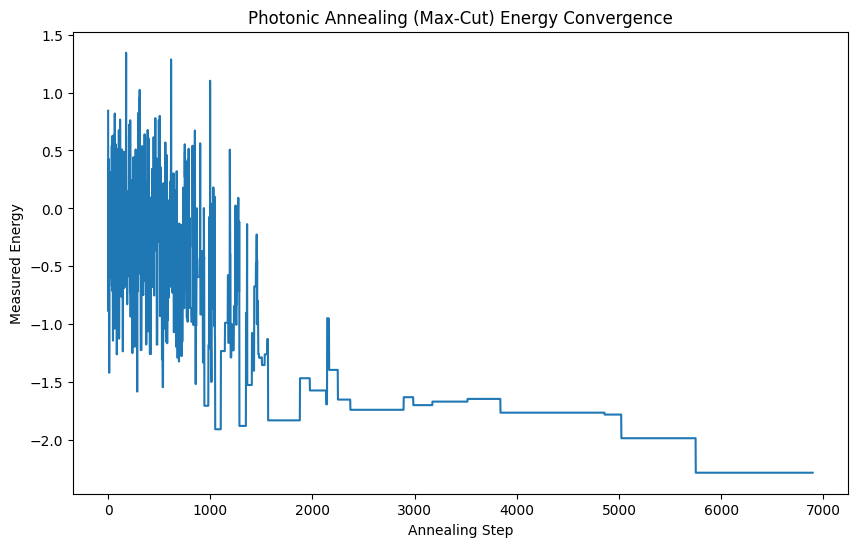


--- PROFILING RESULTS (Average per Mask) ---
1. Mask Generation (Numba):   1.308 ms
2. Buffer Upload (SDK):       28.063 ms
   (Total 'Produce' Time):    29.371 ms
3. SLM Display Call:          30.522 ms
4. Measurement (Settle+Read): 0.252 ms
5. Dead Time (Consumer Wait): 2.387 ms
   Dead Time (Producer Wait): 0.010 ms
--------------------------------------------

Disconnecting hardware...
Photodiode reader thread stopped.
Serial port COM21 closed.
SLM window closed.


AttributeError: type object 'SDK' has no attribute 'Exit'

In [12]:
from time import time


# time.sleep(10)

factorization_annealer = MaxCutAnnealer(J_embedded,347,347, use_uint8=True, factorizing=True)
factorization_annealer.reset_stats()
factorization_annealer.sync_slm = True

# Verify the flag is actually sticking
print(f"DEBUG Check -> use_uint8: {factorization_annealer.use_uint8}, dtype: {factorization_annealer._mask_buffers[0].dtype}")
print(f"DEBUG Check -> sync_slm: {factorization_annealer.sync_slm}")


result_spin, energy, energy_trace  = factorization_annealer.run_annealing(initial_temp=1.0, final_temp=0.001, cooling_rate=0.995, steps_per_temp=5)
factorization_annealer.print_stats()
factorization_annealer.disconnect_hardware()
factorization_annealer.stop_pd_thread()
print(factorization_annealer.stats)

In [7]:
factorization_annealer.print_stats()


--- PROFILING RESULTS (Average per Mask) ---
1. Mask Generation (Numba):   1.051 ms
2. Buffer Upload (SDK):       32.090 ms
   (Total 'Produce' Time):    33.141 ms
3. SLM Display Call:          30.735 ms
4. Measurement (Settle+Read): 0.156 ms
5. Dead Time (Consumer Wait): 2.302 ms
   Dead Time (Producer Wait): 0.011 ms
--------------------------------------------


In [13]:
print("Result Spin Configuration:", result_spin)

Result Spin Configuration: [ 1  1 -1  1  1 -1  1  1]


In [9]:
def get_factors_from_spins(spin_vector, index_to_variable, N):
    """
    Decodes the spin vector from the Ising machine into factors P and Q.
    
    Args:
        spin_vector (list/array): The result from the SPIM (e.g., [-1, 1, 1...])
        index_to_variable (dict): The mapping returned by get_ising_matrix2 ({0: 'q_3'...})
        N (int): The number being factored (for verification).
    """
    
    # --- STEP 1: Handle Ancilla (Augmented Matrix Check) ---
    # If the vector is 1 element longer than the variable map, you used an ancilla.
    num_vars = len(index_to_variable)
    processed_spins = []
    
    if len(spin_vector) == num_vars + 1:
        ancilla = spin_vector[-1]
        system_spins = spin_vector[:-1]
        
        # If ancilla is -1 (down), we must flip the system to get the Ground State
        if ancilla < 0:
            processed_spins = [-s for s in system_spins]
        else:
            processed_spins = system_spins
    elif len(spin_vector) == num_vars:
        processed_spins = spin_vector
    else:
        raise ValueError(f"Size Mismatch: Vector has {len(spin_vector)}, Map has {num_vars}")

    # --- STEP 2: Convert Spins to Binary Dictionary ---
    # Map -1 -> 0 and +1 -> 1
    assignment = {}
    for i, spin in enumerate(processed_spins):
        var_name = index_to_variable[i]
        # x = (s + 1) / 2
        bit = 1 if spin > 0 else 0
        assignment[var_name] = bit

    # --- STEP 3: Reconstruct P and Q ---
    # We initialize with fixed p_0 and q_0 = 1 (standard factorization assumption)
    p_bits = {0: 1}
    q_bits = {0: 1}

    print("Raw Variable Assignment:", assignment)

    for var_name, bit_val in assignment.items():
        # Parse names like 'p_3' or 'q_2'
        if var_name.startswith('p_'):
            try:
                # Extract index from 'p_3' -> 3
                idx = int(var_name.split('_')[1])
                p_bits[idx] = bit_val
            except:
                pass
        elif var_name.startswith('q_'):
            try:
                idx = int(var_name.split('_')[1])
                q_bits[idx] = bit_val
            except:
                pass

    # --- STEP 4: Calculate Integers ---
    P = 0
    Q = 0
    
    # Sum p_i * 2^i
    for idx, bit in p_bits.items():
        P += bit * (2**idx)
        
    # Sum q_i * 2^i
    for idx, bit in q_bits.items():
        Q += bit * (2**idx)

    print(f"Reconstructed Binary P: {p_bits}")
    print(f"Reconstructed Binary Q: {q_bits}")
    print(f"Calculated Factors: {P}, {Q}")
    
    if P * Q == N:
        print("✅ SUCCESS: Factorization Correct!")
    else:
        print(f"❌ MISMATCH: {P} * {Q} = {P*Q} (Expected {N})")
        
    return P, Q

P, Q = get_factors_from_spins(result_spin*-1, index_map, 55)

Raw Variable Assignment: {'x[1]': 1, 'x[4]': 0, 'y[2]': 0, 'y[0]': 0, 'x[2]': 0, 'x[5]': 1, 'x[0]': 1, 'y[1]': 1, 'x[3]': 1, 'w0': 1, 'w0#': 1, 'w0##': 1, 'w1': 0, 'w1#': 1, 'w1##': 1, 'w2': 0, 'w2#': 1, 'w2##': 0, 'w3': 1, 'w3#': 0, 'w3##': 0, 'w4': 1, 'w4#': 1, 'w4##': 0, 'w5': 1, 'w5#': 0, 'w5##': 1, 'w6': 0, 'w7': 1, 'w8': 0, 'w8#': 1, 'w8##': 0, 'w9': 0, 'w9#': 0, 'w9##': 0, 'w10': 0, 'w11': 0, 'w12': 1, 'w12#': 1, 'w12##': 0, 'w13': 1, 'w13#': 1, 'w13##': 0, 'w14': 0, 'w15': 1, 'w16': 0, 'w17': 1, 'w18': 1, 'w19': 1, 'w19#': 1, 'w19##': 1, 'w20': 0, 'w20#': 1, 'w20##': 1, 'w21': 0, 'w22': 0, 'w23': 1, 'w24': 1, 'w25': 0, 'w26': 1, 'w27': 1, 'w28': 0, 'w28#': 0, 'w28##': 1, 'w29': 0, 'w29#': 1, 'w29##': 0, 'w30': 1, 'w31': 1, 'w32': 1, 'w33': 0, 'w34': 0, 'w35': 1, 'w36': 1, 'w36#': 1, 'w36##': 1, 'w37': 1, 'w37#': 0, 'w37##': 1, 'w38': 0, 'w39': 1, 'w40': 0, 'w40#': 0, 'w40##': 1, 'w41': 1, 'w41#': 0, 'w41##': 1, 'w42': 0, 'w43': 1, 'w44': 0, 'w44#': 1, 'w44##': 1, 'w45': 1, 'w45

# Sims and Maxcut

In [6]:
filename = 'MC100.npz'

def data_loader(filename):
    """
    Takes data from .npz and returns adjacency matrix.
    """
    import numpy as np
    import scipy.sparse as sp

    # Load the .npz file
    data = np.load(filename, allow_pickle=True)

    # Reconstruct the sparse adjacency matrix (CSR format)
    adj_sparse = sp.csr_matrix(
        (data['data'], data['indices'], data['indptr']),
        shape=tuple(data['shape'])
    )

    # If you want a dense NumPy array (e.g., for neural nets)
    return adj_sparse.toarray()

Adj = data_loader(filename)



In [7]:
import numpy as np


if __name__ == "__main__":
    # Enable GPU acceleration if available (CRITICAL for 1920x1080 resolution)
    try:
        import diffractsim
        diffractsim.set_backend("CUDA")
        print("CUDA Backend Enabled.")
    except:
        print("Running on CPU. 1920x1080 simulation will be slow (~1-2s per step).")

    # --- Setup Problem ---
    NUM_SPINS = 10
    np.random.seed(42)
    J = np.random.randn(NUM_SPINS, NUM_SPINS)
    J = (J + J.T) / 2
    
    # --- Setup Simulator ---
    # Using 1920x1080 resolution
    # beam_sigma is in PIXELS.
    # If sigma = 600, full width is ~1200 pixels. 
    # SLM width is 1920, so the corners will be significantly darker.
    sim_annealer = SimulatedMaxCutAnnealer(
        J=J,
        beam_sigma_x=600.0, 
        beam_sigma_y=600.0,
        focal_length_cm=50,
        use_uint8=True
    )
    
    print("\n--- Starting High-Res Simulation ---")
    
    sim_annealer.run_annealing(
        initial_temp=5000.0, # Optical energy units can be large
        final_temp=10.0,
        cooling_rate=0.95,
        steps_per_temp=15 
    )

CUDA Backend Enabled.
Initializing MaxCut Annealer...
Initializing Photonic Annealer Base...
 [Simulation] Initializing High-Res Optical Simulation...
 [Simulation] Backend: CUDA. Moving data to GPU...
Base annealer initialized.
Preparing model for 10 spins...
  - SLM Layout: 1 rows x 10 cols
  - Macropixel Size: 192 x 1080 pixels
  - (MaxCut) Performing full eigendecomposition...
  - Identified 10 active eigenmodes.
  - Precomputed alpha matrix ((10, 10)).
Preparation complete.

--- Starting High-Res Simulation ---
Evaluating initial random spin configuration (Max-Cut)...
Initial energy: 1760.0414 (eval time: 1.57s)

Current Temperature: 5000.0000
  Step 1/15 | New Energy Accepted: -1439.2987 (eval: 1.63s)
  Step 2/15 | New Energy Accepted: -15646.3437 (eval: 2.72s)
  Step 3/15 | New Energy Accepted: -15509.1558 (eval: 2.29s)
  Step 8/15 | New Energy Accepted: -15646.3437 (eval: 2.10s)
  Step 9/15 | New Energy Accepted: -15509.1558 (eval: 1.25s)


KeyboardInterrupt: 

In [9]:
try:
    import cupy as cp
    print(f"✅ CuPy is installed. Version: {cp.__version__}")
    if cp.cuda.is_available():
        print(f"✅ GPU is available: {cp.cuda.Device(0).use().name()}")
    else:
        print("❌ CuPy is installed but cannot access the GPU (Check CUDA drivers).")
except ImportError:
    print("❌ CuPy is NOT installed. DiffractSim requires it for GPU mode.")
    print("   Install it via: pip install cupy-cuda12x (or match your CUDA version)")

✅ CuPy is installed. Version: 13.6.0


AttributeError: 'cupy.cuda.device.Device' object has no attribute 'name'

In [9]:
test.disconnect_hardware()


Disconnecting hardware...
Photodiode reader thread stopped.
Serial port COM21 closed.
SLM window closed.


AttributeError: type object 'SDK' has no attribute 'Exit'

In [10]:
# Re-run all imports and class definitions first!

test = MaxCutAnnealer(Adj, 347, 347, use_uint8=True)
test.reset_stats()
test.sync_slm = False
test._buffer_pool_size = 10

# Verify the flag is actually sticking
print(f"DEBUG Check -> use_uint8: {test.use_uint8}, dtype: {test._mask_buffers[0].dtype}")
print(f"DEBUG Check -> sync_slm: {test.sync_slm}")

final_spins, min_energy, energy_data = test.run_annealing(initial_temp=10, final_temp=8, cooling_rate=0.95, steps_per_temp=10)
test.print_stats()

Initializing MaxCut Annealer...
Initializing Photonic Annealer Base...
Connecting to hardware...
SLM connected. Resolution: 1920 x 1080
Serial port COM21 opened at 115200 baud.
Photodiode reader thread started.
Base annealer initialized.
Preparing model for 100 spins...
  - SLM Layout: 5 rows x 20 cols
  - Macropixel Size: 96 x 216 pixels
  - (MaxCut) Performing full eigendecomposition...
  - Identified 100 active eigenmodes.
  - Precomputed alpha matrix ((100, 100)).
Preparation complete.
DEBUG Check -> use_uint8: True, dtype: uint8
DEBUG Check -> sync_slm: False
Evaluating initial random spin configuration (Max-Cut)...
Initial energy: -3.3578 (eval time: 3.61s)

Current Temperature: 10.0000
  Step 1/10 | New Energy Accepted: 1.3780 (eval: 3.22s)
  Step 2/10 | New Energy Accepted: 5.3810 (eval: 3.23s)
  Step 3/10 | New Energy Accepted: -2.6459 (eval: 3.46s)
  Step 5/10 | New Energy Accepted: -26.5492 (eval: 3.31s)
  Step 8/10 | New Energy Accepted: -40.8691 (eval: 3.62s)
  Temp step t

KeyboardInterrupt: 

In [ ]:
import numpy as np

# 1. Generate the array
# 'high' is exclusive, so we use 256 to include 255.
random_array = np.random.randint(low=0, high=256, size=(1920, 1080), dtype=np.uint8)

# Verification
print(f"Shape: {random_array.shape}")
print(f"Data Type: {random_array.dtype}")
print(f"Min: {random_array.min()}, Max: {random_array.max()}")

In [3]:
from HEDS import *
from HEDS import holoeye_slmdisplaysdk_slm as heds

def connect_slm():
    heds.SDK.Init(4,1)
    slm = heds.SLM.Init(openPreview=True, previewScale=1)

    # Check for errors
    if slm.errorCode() != heds.HEDSERR_NoError:
        print(f"Error connecting to SLM: {heds.SDK.errorString(slm.errorCode())}")
    else:
        # 3. If the connection is successful, you can now display data on the SLM.
        #    Here, we'll just show a blank screen.
        slm.showBlankScreen(000) # Show a mid-gray screen
        print("connected")
    return slm

In [4]:
slm = connect_slm()

connected


In [4]:
import time
import numpy as np
import HEDS
from hedslib.heds_types import *

# 1. Initialize
HEDS.SDK.Init(4, 1)

try:
    print("Initializing Pluto with OpenGL backend...")
    # TRY THIS FIX: Add "-gapi OpenGL" to bypass DirectX overhead
    slm = HEDS.SLM.Init(preselect="name:pluto -gapi OpenGL", openPreview=False)
    
    width = slm.width_px()
    height = slm.height_px()
    print(f"SLM Ready: {width}x{height} @ {slm.refreshrate_hz()}Hz")
    
    # 2. Pre-load 100 frames
    print("Pre-loading 100 frames to GPU...")
    handles = []
    data_field = HEDS.SLMDataField(width, height, data_format=HEDSDTFMT_FLOAT_32)
    input_buffer = data_field.data()
    
    # Generate random data
    for i in range(100):
        # Generate simple noise
        input_buffer[:] = np.random.random((height, width, 1)).astype(np.float32) * (2 * np.pi)
        err, h = slm.loadPhaseData(data_field)
        if err == HEDSERR_NoError:
            handles.append(h)
            
    print("Starting Playback...")
    
    # 3. Playback Loop
    start_time = time.perf_counter()
    
    for handle in handles:
        # This sends the "Show" command. 
        # If it blocks, it means the queue is full (good, means we are maxing out the SLM).
        handle.show()
        
    # Wait for the LAST handle to actually finish appearing on screen
    # This ensures our timer includes the full display time
    handles[-1].waitforState(HEDSDHST_Visible)
    
    end_time = time.perf_counter()
    
    # 4. Results
    total_time = end_time - start_time
    fps = 100 / total_time
    print("-" * 30)
    print(f"Total Time: {total_time:.4f}s")
    print(f"Throughput: {fps:.2f} FPS")
    print("-" * 30)
    
    # 5. DIAGNOSTICS (Frame #50)
    # We check a frame from the middle of the batch to see if it stuck on screen too long.
    mid_handle = handles[50]
    
    print("\n--- DIAGNOSTICS (Frame #50) ---")
    # This string contains "Visible Duration"
    print(mid_handle.getTimingPrintString())
    
    # Check if we hit the target
    if fps > 59.0:
        print("\nSUCCESS: 60Hz Locked.")
    else:
        print("\nDIAGNOSIS:")
        print("If FPS is still ~47, the Windows Compositor is forcing a delay.")
        print("Ensure 'High Performance' is set in WINDOWS SETTINGS (not just Nvidia panel).")

except Exception as e:
    print(f"Error: {e}")

finally:
    try:
        # Cleanup
        for h in handles: h.release()
        slm.close()
    except:
        pass
    HEDS.SDK.Close()

Initializing Pluto with OpenGL backend...
SLM Ready: 1920x1080 @ 60.0Hz
Pre-loading 100 frames to GPU...
Starting Playback...
------------------------------
Total Time: 3.2686s
Throughput: 30.59 FPS
------------------------------

--- DIAGNOSTICS (Frame #50) ---
ID: 0051 | Render Duration:   0ms | Visible Duration:  30ms

DIAGNOSIS:
If FPS is still ~47, the Windows Compositor is forcing a delay.
Ensure 'High Performance' is set in WINDOWS SETTINGS (not just Nvidia panel).


In [3]:
import numpy as np

def generate_maxcut_graph(n_nodes):
    """
    Generates a random adjacency matrix for a max-cut graph with a given number of nodes.

    Args:
        n_nodes (int): The number of nodes in the graph.

    Returns:
        np.ndarray: A symmetric, 10x10 NumPy array representing the adjacency matrix.
    """
    # Create a random symmetric matrix with 0s and 1s
    rand_matrix = np.random.randint(0, 2, size=(n_nodes, n_nodes))
    
    # Ensure the matrix is symmetric
    adj_matrix = rand_matrix + rand_matrix.T
    
    # Set the diagonal to zero to remove self-loops
    np.fill_diagonal(adj_matrix, 0)
    
    # Ensure entries are only 0 or 1
    adj_matrix[adj_matrix > 1] = 1

    return adj_matrix

# Generate a random adjacency matrix for a 10-spin graph
graph_matrix = generate_maxcut_graph(10)

print(graph_matrix)


[[0 0 1 0 1 1 0 1 0 1]
 [0 0 0 1 1 1 1 0 1 0]
 [1 0 0 1 1 0 1 1 0 1]
 [0 1 1 0 1 0 1 1 1 1]
 [1 1 1 1 0 1 0 1 1 1]
 [1 1 0 0 1 0 1 0 0 1]
 [0 1 1 1 0 1 0 1 0 1]
 [1 0 1 1 1 0 1 0 1 1]
 [0 1 0 1 1 0 0 1 0 1]
 [1 0 1 1 1 1 1 1 1 0]]


In [ ]:
factorization_annealer.disconnect_hardware()

In [4]:
test = MaxCutAnnealer(Adj, 347, 347, use_uint8=True)

Initializing MaxCut Annealer...
Initializing Photonic Annealer Base...
Connecting to hardware...
SLM connected. Resolution: 1920 x 1080
Failed to connect to serial port COM21: could not open port 'COM21': FileNotFoundError(2, 'The system cannot find the file specified.', None, 2)
Continuing in offline mode. Photodiode will not be read.
Base annealer initialized.
Preparing model for 100 spins...
  - SLM Layout: 5 rows x 20 cols
  - Macropixel Size: 96 x 216 pixels
  - (MaxCut) Performing full eigendecomposition...
  - Identified 93 active eigenmodes.
  - Precomputed alpha matrix ((100, 93)).
Preparation complete.


Evaluating initial random spin configuration (Max-Cut)...
Initial energy: -5.1739 (eval time: 6.08s)

Current Temperature: 10.0000
  Step 1/10 | New Energy Accepted: -13.8014 (eval: 3.00s)
  Temp step took 29.99s

Current Temperature: 9.5000
  Step 3/10 | New Energy Accepted: -18.6462 (eval: 3.01s)
  Step 4/10 | New Energy Accepted: -10.0655 (eval: 3.00s)
  Step 5/10 | New Energy Accepted: -3.6283 (eval: 3.04s)
  Step 8/10 | New Energy Accepted: -5.6546 (eval: 3.00s)
  Step 10/10 | New Energy Accepted: -7.1613 (eval: 2.99s)
  Temp step took 30.07s

Current Temperature: 9.0250
  Step 2/10 | New Energy Accepted: -2.2981 (eval: 3.01s)
  Step 4/10 | New Energy Accepted: 4.1647 (eval: 3.03s)
  Step 5/10 | New Energy Accepted: 8.0632 (eval: 3.02s)
  Step 6/10 | New Energy Accepted: -5.9985 (eval: 3.01s)
  Step 9/10 | New Energy Accepted: 2.0019 (eval: 3.01s)
  Step 10/10 | New Energy Accepted: 4.5613 (eval: 3.02s)
  Temp step took 30.15s

Current Temperature: 8.5738
  Step 1/10 | New Energy 

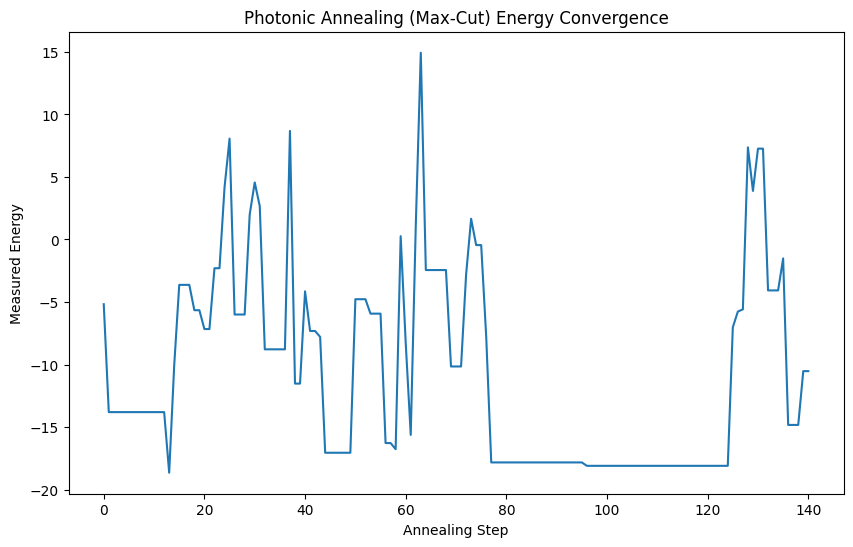


--- PROFILING RESULTS (Average per Mask) ---
1. Mask Generation (Numba):   0.864 ms
2. Buffer Upload (SDK):       17.183 ms
   (Total 'Produce' Time):    18.047 ms
3. SLM Display Call:          32.074 ms
4. Measurement (Settle+Read): 0.096 ms
5. Dead Time (Consumer Wait): 0.279 ms
   Dead Time (Producer Wait): 12.121 ms
--------------------------------------------


In [5]:
test.reset_stats()
test.sync_slm = False

final_spins, min_energy, energy_data = test.run_annealing(initial_temp=10, final_temp=5, cooling_rate=0.95, steps_per_temp=10)

test.print_stats()

Evaluating initial random spin configuration (Max-Cut)...
Initial energy: 2.1844 (eval time: 3.10s)

Current Temperature: 10.0000
  Step 1/10 | New Energy Accepted: -8.3004 (eval: 3.09s)
  Step 2/10 | New Energy Accepted: 0.1875 (eval: 3.12s)
  Step 3/10 | New Energy Accepted: -11.2071 (eval: 3.09s)
  Step 6/10 | New Energy Accepted: -5.9162 (eval: 3.10s)
  Step 7/10 | New Energy Accepted: -5.7388 (eval: 3.09s)
  Step 9/10 | New Energy Accepted: 1.0928 (eval: 3.11s)
  Temp step took 31.02s

Current Temperature: 9.5000
  Step 1/10 | New Energy Accepted: -12.2251 (eval: 3.10s)
  Step 5/10 | New Energy Accepted: -11.8697 (eval: 3.12s)
  Step 6/10 | New Energy Accepted: -12.5053 (eval: 3.09s)
  Step 7/10 | New Energy Accepted: -5.1202 (eval: 3.11s)
  Step 8/10 | New Energy Accepted: -6.3886 (eval: 3.09s)
  Step 9/10 | New Energy Accepted: -11.0695 (eval: 3.13s)
  Temp step took 31.05s

Current Temperature: 9.0250
  Step 4/10 | New Energy Accepted: -0.6282 (eval: 3.10s)
  Step 5/10 | New En

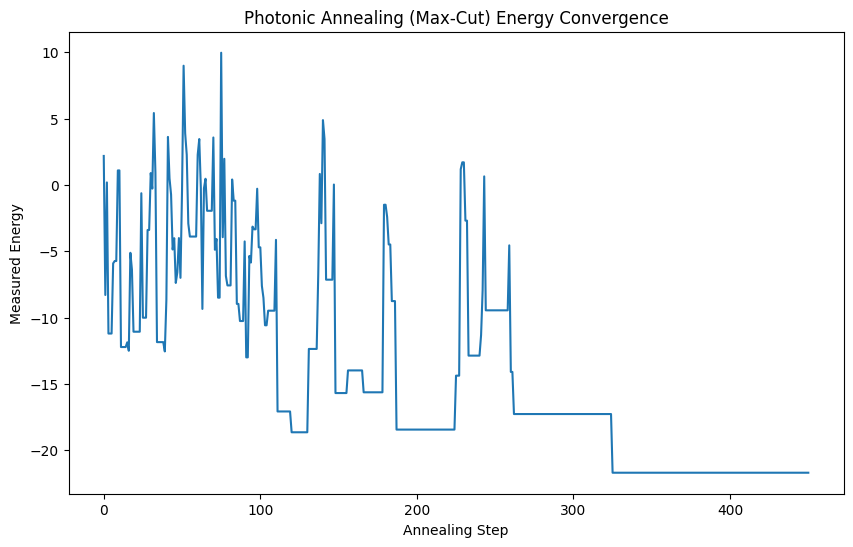


--- PROFILING RESULTS (Average per Mask) ---
1. Mask Generation (Numba):   0.772 ms
2. Buffer Upload (SDK):       4.657 ms
   (Total 'Produce' Time):    5.428 ms
3. SLM Display Call:          17.676 ms
4. Measurement (Settle+Read): 15.595 ms
5. Dead Time (Consumer Wait): 0.061 ms
   Dead Time (Producer Wait): 25.168 ms
--------------------------------------------
Evaluating initial random spin configuration (Max-Cut)...
Initial energy: -6.4704 (eval time: 3.09s)

Current Temperature: 10.0000
  Step 1/10 | New Energy Accepted: -11.4569 (eval: 3.10s)
  Step 3/10 | New Energy Accepted: 0.2664 (eval: 3.08s)
  Step 6/10 | New Energy Accepted: 2.1858 (eval: 3.11s)
  Step 8/10 | New Energy Accepted: -6.7094 (eval: 3.10s)
  Step 9/10 | New Energy Accepted: 1.8246 (eval: 3.10s)
  Temp step took 31.00s

Current Temperature: 9.5000
  Step 1/10 | New Energy Accepted: 2.7805 (eval: 3.12s)
  Step 2/10 | New Energy Accepted: 11.9990 (eval: 3.09s)
  Step 3/10 | New Energy Accepted: 10.8788 (eval: 3.1

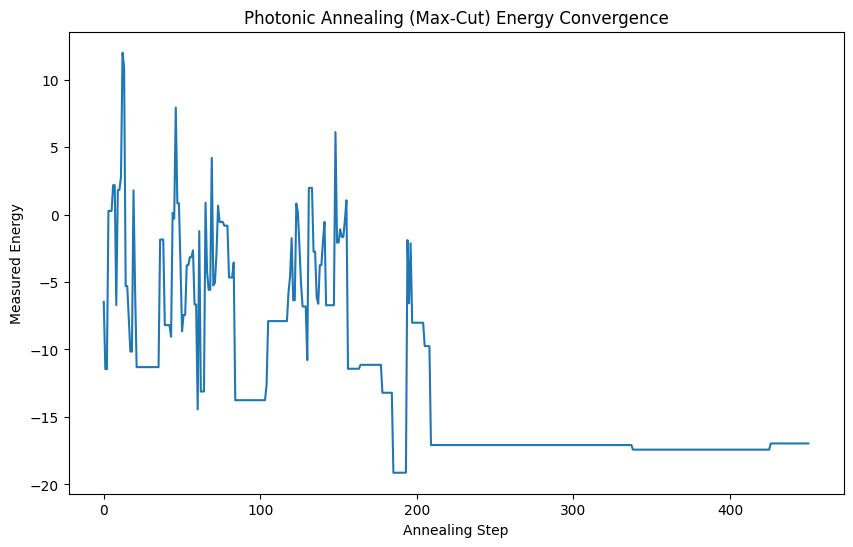


--- PROFILING RESULTS (Average per Mask) ---
1. Mask Generation (Numba):   0.678 ms
2. Buffer Upload (SDK):       5.173 ms
   (Total 'Produce' Time):    5.851 ms
3. SLM Display Call:          17.577 ms
4. Measurement (Settle+Read): 15.587 ms
5. Dead Time (Consumer Wait): 0.065 ms
   Dead Time (Producer Wait): 24.649 ms
--------------------------------------------
Evaluating initial random spin configuration (Max-Cut)...
Initial energy: -19.1807 (eval time: 3.09s)

Current Temperature: 10.0000
  Step 2/10 | New Energy Accepted: 3.9873 (eval: 3.10s)
  Step 3/10 | New Energy Accepted: 4.0018 (eval: 3.10s)
  Step 4/10 | New Energy Accepted: -8.1899 (eval: 3.10s)
  Step 6/10 | New Energy Accepted: 6.8613 (eval: 3.09s)
  Step 7/10 | New Energy Accepted: -14.1836 (eval: 3.11s)
  Step 9/10 | New Energy Accepted: -6.9684 (eval: 3.10s)
  Step 10/10 | New Energy Accepted: -0.7303 (eval: 3.10s)
  Temp step took 31.00s

Current Temperature: 9.5000
  Step 1/10 | New Energy Accepted: 1.1737 (eval: 3

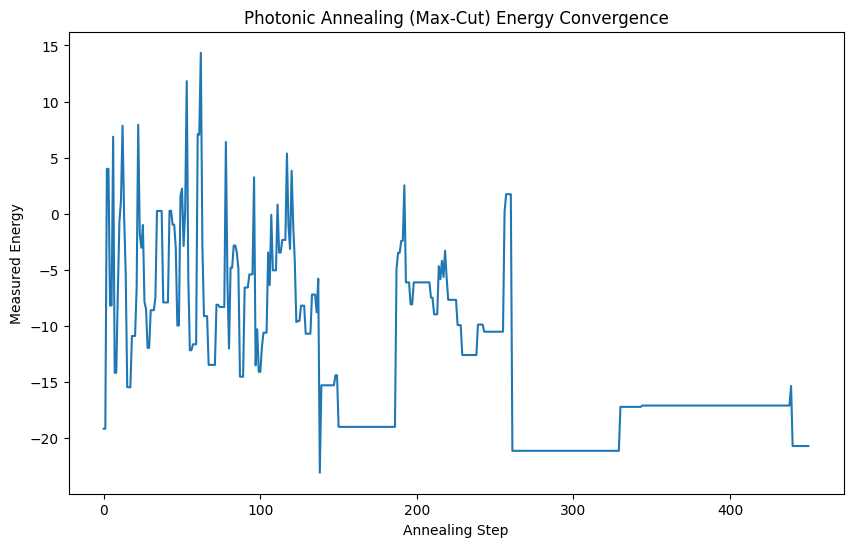


--- PROFILING RESULTS (Average per Mask) ---
1. Mask Generation (Numba):   0.673 ms
2. Buffer Upload (SDK):       5.694 ms
   (Total 'Produce' Time):    6.367 ms
3. SLM Display Call:          17.572 ms
4. Measurement (Settle+Read): 15.587 ms
5. Dead Time (Consumer Wait): 0.072 ms
   Dead Time (Producer Wait): 24.136 ms
--------------------------------------------
Evaluating initial random spin configuration (Max-Cut)...
Initial energy: 2.6053 (eval time: 3.09s)

Current Temperature: 10.0000
  Step 1/10 | New Energy Accepted: 3.4717 (eval: 3.09s)
  Step 2/10 | New Energy Accepted: -12.8692 (eval: 3.11s)
  Step 3/10 | New Energy Accepted: -11.6624 (eval: 3.09s)
  Step 5/10 | New Energy Accepted: -10.3350 (eval: 3.11s)
  Step 7/10 | New Energy Accepted: -11.7298 (eval: 3.09s)
  Temp step took 31.00s

Current Temperature: 9.5000
  Step 1/10 | New Energy Accepted: 7.7701 (eval: 3.11s)
  Step 2/10 | New Energy Accepted: -3.8341 (eval: 3.10s)
  Step 4/10 | New Energy Accepted: -7.0325 (eval:

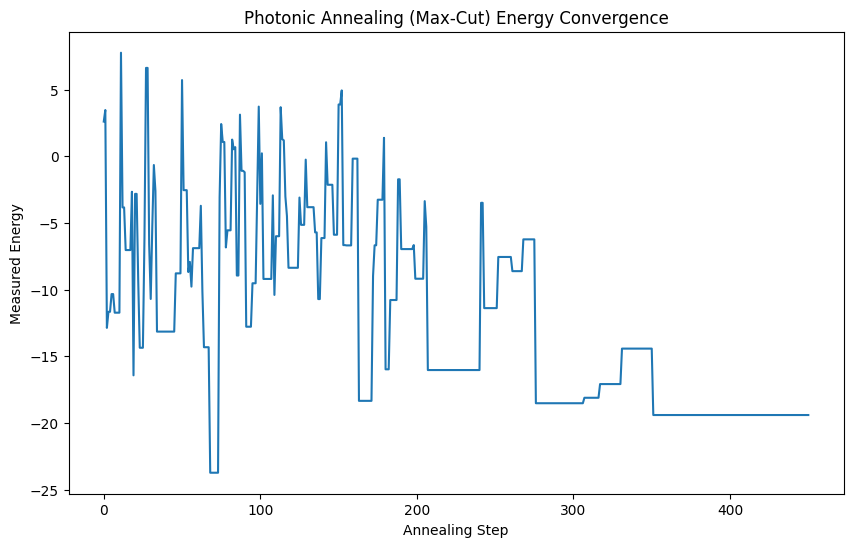


--- PROFILING RESULTS (Average per Mask) ---
1. Mask Generation (Numba):   0.716 ms
2. Buffer Upload (SDK):       6.092 ms
   (Total 'Produce' Time):    6.808 ms
3. SLM Display Call:          17.552 ms
4. Measurement (Settle+Read): 15.609 ms
5. Dead Time (Consumer Wait): 0.077 ms
   Dead Time (Producer Wait): 23.710 ms
--------------------------------------------
Evaluating initial random spin configuration (Max-Cut)...
Initial energy: 8.6037 (eval time: 3.09s)

Current Temperature: 10.0000
  Step 1/10 | New Energy Accepted: 10.8703 (eval: 3.10s)
  Step 2/10 | New Energy Accepted: -4.0239 (eval: 3.10s)
  Step 4/10 | New Energy Accepted: 1.8855 (eval: 3.11s)
  Step 5/10 | New Energy Accepted: 2.8439 (eval: 3.10s)
  Step 6/10 | New Energy Accepted: -4.4509 (eval: 3.09s)
  Step 9/10 | New Energy Accepted: 8.2780 (eval: 3.09s)
  Step 10/10 | New Energy Accepted: -8.9734 (eval: 3.10s)
  Temp step took 31.00s

Current Temperature: 9.5000
  Step 8/10 | New Energy Accepted: 4.5242 (eval: 3.09

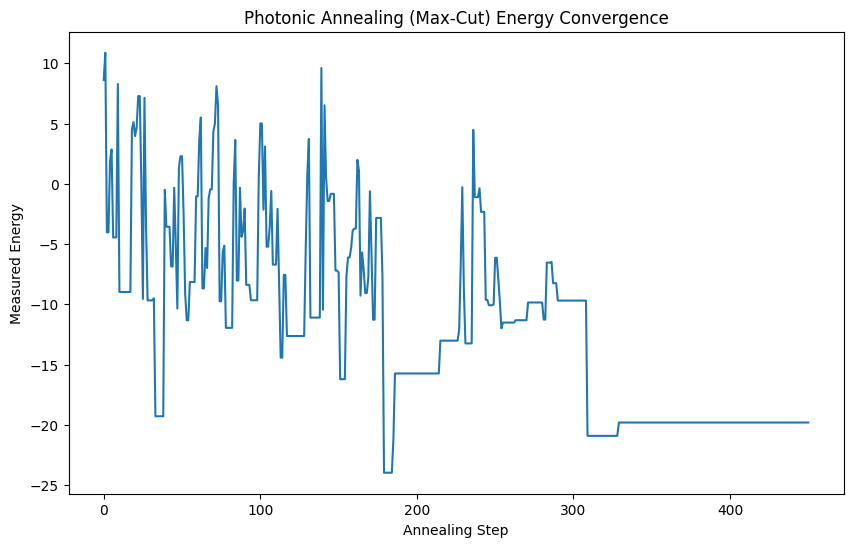


--- PROFILING RESULTS (Average per Mask) ---
1. Mask Generation (Numba):   0.732 ms
2. Buffer Upload (SDK):       6.433 ms
   (Total 'Produce' Time):    7.166 ms
3. SLM Display Call:          17.577 ms
4. Measurement (Settle+Read): 15.582 ms
5. Dead Time (Consumer Wait): 0.081 ms
   Dead Time (Producer Wait): 23.362 ms
--------------------------------------------
Evaluating initial random spin configuration (Max-Cut)...
Initial energy: -1.6586 (eval time: 3.08s)

Current Temperature: 10.0000
  Step 1/10 | New Energy Accepted: -8.2950 (eval: 3.11s)
  Step 2/10 | New Energy Accepted: -6.5756 (eval: 3.11s)
  Step 3/10 | New Energy Accepted: -7.0123 (eval: 3.10s)
  Step 4/10 | New Energy Accepted: -4.1655 (eval: 3.10s)
  Step 5/10 | New Energy Accepted: -4.6917 (eval: 3.10s)
  Step 6/10 | New Energy Accepted: -18.6657 (eval: 3.09s)
  Temp step took 31.03s

Current Temperature: 9.5000
  Step 2/10 | New Energy Accepted: -13.5492 (eval: 3.10s)
  Step 4/10 | New Energy Accepted: -0.5841 (eval

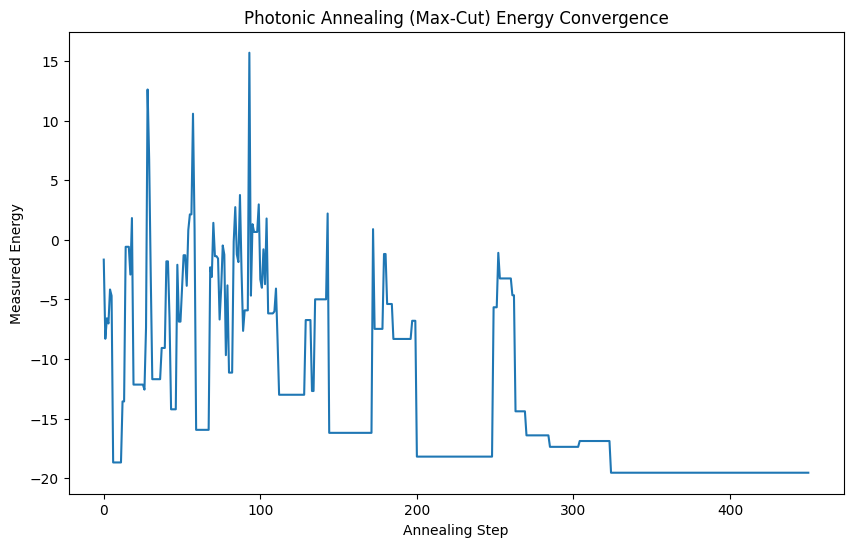


--- PROFILING RESULTS (Average per Mask) ---
1. Mask Generation (Numba):   0.721 ms
2. Buffer Upload (SDK):       6.666 ms
   (Total 'Produce' Time):    7.387 ms
3. SLM Display Call:          17.577 ms
4. Measurement (Settle+Read): 15.572 ms
5. Dead Time (Consumer Wait): 0.085 ms
   Dead Time (Producer Wait): 23.142 ms
--------------------------------------------


In [12]:
stats_buffersize = []

buff = [1,4,8,12,16,20]

for size in buff:
    test.reset_stats()
    test._buffer_pool_size = size

    final_spins, min_energy, energy_data = test.run_annealing(initial_temp=10, final_temp=1, cooling_rate=0.95, steps_per_temp=10)
    stats_buffersize.append(test.stats.copy())
    test.print_stats()

In [9]:
for i in range (len(buff)):
    print(f"Buffer Size: {buff[i]}")
    for key in stats_buffersize[i]:
        print(f"{key}: {stats_buffersize[i][key]}")

Buffer Size: 1
mask_gen: 31.510686100526073
buffer_upload: 994.4385339996443
slm_show: 983.3523804995566
measurement: 348.94458770049096
queue_wait: 4.2916858999597025
producer_wait: 236.0477547991104
count_masks: 41943.0
count_evals: 0.0
Buffer Size: 4
mask_gen: 24.971695000458567
buffer_upload: 1022.9173605999968
slm_show: 984.8724821999349
measurement: 338.01340499949583
queue_wait: 2.80923570075538
producer_wait: 203.11218839875073
count_masks: 41943.0
count_evals: 0.0
Buffer Size: 8
mask_gen: 24.70039610054664
buffer_upload: 1040.1039005005878
slm_show: 979.9137314005493
measurement: 339.15945849905984
queue_wait: 3.1344058985923766
producer_wait: 184.083322098777
count_masks: 41943.0
count_evals: 0.0
Buffer Size: 12
mask_gen: 24.60763060003228
buffer_upload: 1053.1132796999736
slm_show: 975.0404257994887
measurement: 343.74920440025744
queue_wait: 3.421238400034781
producer_wait: 171.76520269969478
count_masks: 41943.0
count_evals: 0.0
Buffer Size: 16
mask_gen: 26.498707999380713

In [7]:
test.run_annealing(
    initial_temp=1000,
    final_temp=1,
    temp_steps=10,
    steps_per_temp=1000,
    cooling_rate=0.9
)

NameError: name 'test' is not defined

Evaluating initial random spin configuration...
Initial energy: 29.1504 (eval time: 5.10s)

Current Temperature: 1.0000
  Step 1/1 | New Energy Accepted: -0.7002
  Temp step took 3.34s

Current Temperature: 0.9500
  Step 1/1 | New Energy Accepted: -2.1385
  Temp step took 3.42s

Current Temperature: 0.9025
  Step 1/1 | New Energy Accepted: -4.4742
  Temp step took 3.32s

Current Temperature: 0.8574
  Step 1/1 | New Energy Accepted: -4.3315
  Temp step took 3.50s

Current Temperature: 0.8145
  Step 1/1 | New Energy Accepted: -6.2346
  Temp step took 3.35s

Current Temperature: 0.7738
  Temp step took 3.33s

Current Temperature: 0.7351
  Temp step took 3.32s

Current Temperature: 0.6983
  Step 1/1 | New Energy Accepted: -13.2349
  Temp step took 3.37s

Current Temperature: 0.6634
  Temp step took 10.90s

Current Temperature: 0.6302
  Temp step took 3.36s

Current Temperature: 0.5987
  Temp step took 3.30s

Current Temperature: 0.5688
  Temp step took 3.35s

Current Temperature: 0.5404
  

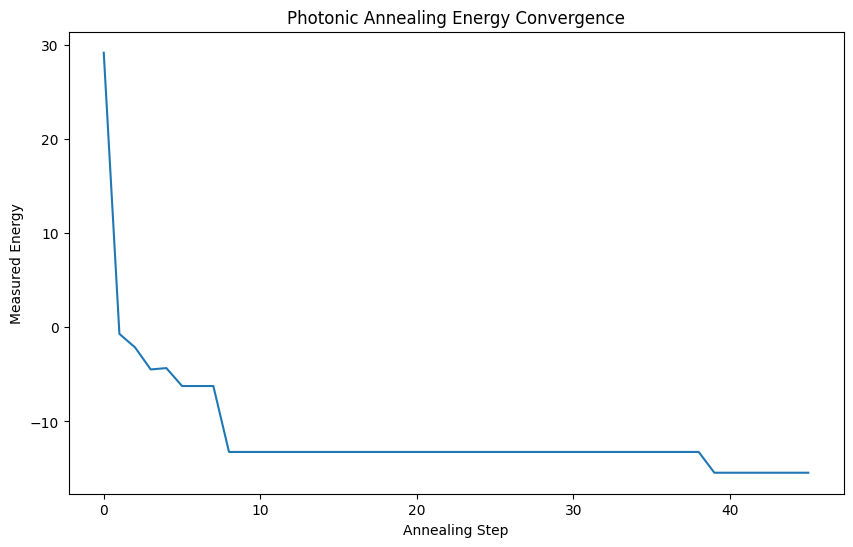

In [5]:
# --- 3. Define Annealing Parameters ---
INITIAL_TEMP = 1.0
FINAL_TEMP = 0.1
COOLING_RATE = 0.95
STEPS_PER_TEMP = 1 # Set low for testing, increase for real runs

import logging


final_spins, energy_data = test.run_annealing(
            initial_temp=INITIAL_TEMP,
            final_temp=FINAL_TEMP,
            cooling_rate=COOLING_RATE,
            steps_per_temp=STEPS_PER_TEMP
        )

In [7]:
test.disconnect_hardware()


Disconnecting hardware...
SLM window closed.


AttributeError: type object 'SDK' has no attribute 'Exit'

In [7]:
import time
print(energy_data)
copy_energy_data = energy_data.copy()

diction = {'energy': copy_energy_data,
           'spins': final_spins
           }

name = str(time.time())

np.savez(f"data_{name}.npz", **diction)

[29.150384392974587, -0.7002404496692378, -2.138491184688519, -4.4742405059433, -4.331526221872608, -6.2346297918522, -6.2346297918522, -6.2346297918522, -13.234884502367663, -13.234884502367663, -13.234884502367663, -13.234884502367663, -13.234884502367663, -13.234884502367663, -13.234884502367663, -13.234884502367663, -13.234884502367663, -13.234884502367663, -13.234884502367663, -13.234884502367663, -13.234884502367663, -13.234884502367663, -13.234884502367663, -13.234884502367663, -13.234884502367663, -13.234884502367663, -13.234884502367663, -13.234884502367663, -13.234884502367663, -13.234884502367663, -13.234884502367663, -13.234884502367663, -13.234884502367663, -13.234884502367663, -13.234884502367663, -13.234884502367663, -13.234884502367663, -13.234884502367663, -13.234884502367663, -15.438940730644802, -15.438940730644802, -15.438940730644802, -15.438940730644802, -15.438940730644802, -15.438940730644802, -15.438940730644802]


In [8]:
for i in range(len(energy_data)):
    if i == len(energy_data) - 1:
        break
    if energy_data[i] < energy_data[i+1]:
        energy_data[i+1] = energy_data[i]

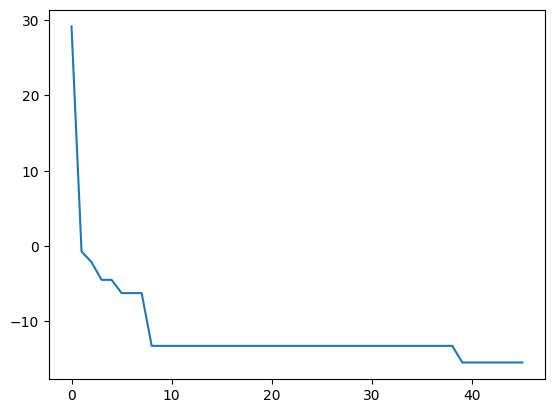

In [9]:
import matplotlib.pyplot as plt
plt.plot(energy_data)

In [10]:
print(final_spins)

[-1  1  1 -1  1 -1 -1  1 -1 -1  1  1 -1 -1 -1 -1  1  1  1 -1 -1 -1 -1 -1
 -1 -1 -1 -1  1 -1  1 -1  1  1  1  1 -1  1 -1 -1  1 -1 -1  1 -1 -1  1  1
  1  1 -1  1 -1 -1  1  1 -1 -1  1  1 -1 -1  1  1  1 -1  1 -1 -1 -1 -1 -1
  1  1  1  1  1 -1 -1  1 -1  1 -1 -1  1  1 -1  1  1 -1 -1 -1  1 -1  1  1
 -1  1  1  1]


In [11]:
def get_cut_value(adj_matrix, spins):
    """
    Calculates the value of a cut given an adjacency matrix and spin assignments.

    The cut value is the sum of weights of all edges that cross the partition.
    An edge (i, j) crosses the partition if node i and node j have different spins.

    Args:
        adj_matrix (list[list[float]] or np.ndarray): 
            A 2D list or NumPy array representing the weighted adjacency matrix 
            of the graph. adj_matrix[i][j] is the weight of the edge between 
            node i and node j. Assumed to be symmetric.
        
        spins (list[int] or np.ndarray): 
            A 1D list or array of spin assignments for each node.
            Typically +1 or -1, where +1 represents one partition and -1 
            represents the other. Must be the same length as the number of nodes.

    Returns:
        float: The total weight of the edges crossing the cut.
        
    Raises:
        ValueError: If the dimensions of the matrix and spin vector do not match.
    """
    
    num_nodes = len(adj_matrix)
    
    # --- Input Validation ---
    if num_nodes == 0:
        return 0
    if num_nodes != len(adj_matrix[0]):
        raise ValueError("Adjacency matrix must be square.")
    if num_nodes != len(spins):
        raise ValueError(f"Spin list length ({len(spins)}) must match the "
                         f"number of nodes ({num_nodes}).")

    cut_value = 0.0

    # Iterate over the upper triangle of the adjacency matrix
    # This ensures we count each edge (i, j) only once
    for i in range(num_nodes):
        for j in range(i + 1, num_nodes):
            
            edge_weight = adj_matrix[i][j]
            
            # Check if an edge exists
            if edge_weight > 0:
                # Check if the nodes are in different partitions (spins are different)
                if spins[i] != spins[j]:
                    # If they are, this edge crosses the cut. Add its weight.
                    cut_value += edge_weight
                    
    return cut_value
cut_value = get_cut_value(Adj, final_spins)
print(cut_value)

1235.0


In [5]:
#!/usr/bin/env python3

"""
Reads a graph file in the format specified (e.g., G11.txt)
and generates a weighted adjacency matrix.
"""

import numpy as np
import sys

def create_adjacency_matrix(filepath):
    """
    Parses a graph file and returns its weighted adjacency matrix.

    The file format expected is:
    Line 1: N M (Number_of_Nodes Number_of_Edges)
    Subsequent lines: u v w (node1 node2 weight)
    
    Assumes nodes are 1-indexed in the file.
    """
    print(f"Reading graph data from {filepath}...")
    
    try:
        with open(filepath, 'r') as f:
            # Read the first line to get the matrix dimensions
            try:
                first_line = f.readline()
                N, M = map(int, first_line.split())
            except Exception as e:
                print(f"Error: Could not read N, M from first line. {e}", file=sys.stderr)
                return None

            print(f"Found {N} nodes and {M} edges.")

            # Initialize an NxN matrix with zeros.
            # Using int dtype because all weights in the sample are integers.
            adj_matrix = np.zeros((N, N), dtype=int)

            # Process the rest of the lines (the edges)
            line_number = 1
            for line in f:
                line_number += 1
                try:
                    parts = line.split()
                    if not parts:
                        continue  # Skip empty lines

                    # Get edge data
                    u, v, weight = map(int, parts)
                    
                    # --- IMPORTANT ---
                    # The file is 1-indexed (nodes 1 to 800)
                    # Numpy arrays are 0-indexed (indices 0 to 799)
                    # We must subtract 1 from the node IDs.
                    u_idx = u - 1
                    v_idx = v - 1

                    # Check for out-of-bounds, just in case
                    if (0 <= u_idx < N) and (0 <= v_idx < N):
                        # This creates a weighted, directed graph matrix
                        adj_matrix[u_idx, v_idx] = weight
                        
                        # --- ADD THIS LINE ---
                        # For an undirected graph, set the symmetric entry
                        adj_matrix[v_idx, u_idx] = weight
                    else:
                        print(f"Warning: Skipping out-of-bounds edge at line {line_number}: {u} -> {v}", file=sys.stderr)

                except ValueError:
                    print(f"Warning: Skipping malformed line {line_number}: {line.strip()}", file=sys.stderr)
                except Exception as e:
                    print(f"Error on line {line_number}: {e}", file=sys.stderr)

            print("Adjacency matrix created successfully.")
            return adj_matrix

    except FileNotFoundError:
        print(f"Error: File not found at {filepath}", file=sys.stderr)
        return None
    except Exception as e:
        print(f"An unexpected error occurred: {e}", file=sys.stderr)
        return None

if __name__ == "__main__":
    # The file you uploaded
    FILE_PATH = 'G17.txt'
    
    matrix = create_adjacency_matrix(FILE_PATH)
    
    if matrix is not None:
        print(f"\nMatrix shape: {matrix.shape}")
        
        # --- Printing ---
        # An 800x800 matrix is too large to print to the console.
        # We'll print just the top-left 5x5 corner as a sample.
        print("\nTop-left 5x5 corner of the matrix:")
        print(matrix[:5, :5])

        # --- Saving (Optional) ---
        # If you want to save the full matrix to a file (e.g., a CSV):
        # 1. Make sure you have numpy installed: pip install numpy
        # 2. Uncomment the two lines below:
        
        # output_filename = "adjacency_matrix.csv"
        # np.savetxt(output_filename, matrix, fmt='%d', delimiter=',')
        # print(f"\nFull adjacency matrix saved to {output_filename}")

Reading graph data from G17.txt...
Found 800 nodes and 4667 edges.
Adjacency matrix created successfully.

Matrix shape: (800, 800)

Top-left 5x5 corner of the matrix:
[[0 1 1 1 1]
 [1 0 1 1 1]
 [1 1 0 1 0]
 [1 1 1 0 1]
 [1 1 0 1 0]]


In [23]:
import numpy as np

def simulated_annealing_ising(J,
                              initial_temp=1.0,
                              final_temp=0.01,
                              cooling_rate=0.95,
                              steps_per_temp=100,
                              seed=None,
                              record_every_step=True):
    """
    Classical simulated annealing for an Ising Hamiltonian.

    Args:
        J (array_like): NxN coupling (adjacency) matrix. If not symmetric it will be symmetrized.
        initial_temp (float): starting temperature.
        final_temp (float): stopping temperature.
        cooling_rate (float): multiplicative factor <1 to reduce temperature each epoch.
        steps_per_temp (int): number of single-spin flip attempts per temperature.
        seed (int or np.random.Generator, optional): RNG seed or generator.
        record_every_step (bool): if True, returns energy recorded at each attempted flip;
                                  otherwise returns one energy per temperature.

    Returns:
        spins (np.ndarray): final spin vector of +1 / -1 (shape (N,)).
        energy_history (list): recorded energies (floats).
    """
    J = np.asarray(J, dtype=float)
    if J.ndim != 2 or J.shape[0] != J.shape[1]:
        raise ValueError("J must be a square matrix")
    # ensure symmetry
    J = 0.5 * (J + J.T)

    n = J.shape[0]
    # RNG
    if isinstance(seed, np.random.Generator):
        rng = seed
    else:
        rng = np.random.default_rng(seed)

    # initialize spins randomly to +1/-1
    spins = rng.choice([-1, 1], size=n)
    spins[-1] = 1  # fix last spin to +1 to break symmetry

    # energy function E = -0.5 * sum_ij J_ij s_i s_j
    def compute_energy(s):
        return -0.5 * float(s @ (J @ s))

    current_energy = compute_energy(spins)
    energy_history = [current_energy]

    T = float(initial_temp)
    while T > final_temp:
        for _ in range(steps_per_temp):
            k = rng.integers(n)  # pick a random spin
            # local field h_k = sum_j J_kj s_j
            h_k = J[k].dot(spins)
            # deltaE for flipping s_k: ΔE = 2 * s_k * h_k
            deltaE = 2.0 * spins[k] * h_k

            if deltaE <= 0.0 or rng.random() < np.exp(-deltaE / T):
                # accept flip
                spins[k] = -spins[k]
                current_energy += deltaE

            if record_every_step:
                energy_history.append(current_energy)

        if not record_every_step:
            energy_history.append(current_energy)

        T *= cooling_rate

    # ensure spins are integer +1/-1
    spins = spins.astype(int)
    return spins, energy_history

Final Spins from Classical SA: [ 1  1 -1  1 -1 -1  1  1]


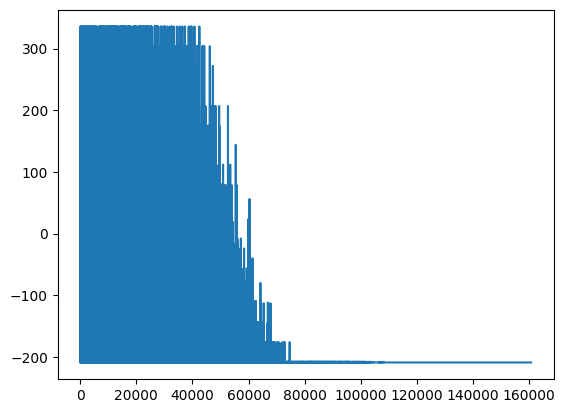

In [27]:
import matplotlib.pyplot as plt
final_spins, energy_trace = simulated_annealing_ising(J_embedded*-1 ,
                                                        initial_temp=10000.0,
                                                        final_temp=0.001,
                                                        cooling_rate=0.995,
                                                        steps_per_temp=50,
                                                        seed=42,
                                                        record_every_step=True)

print("Final Spins from Classical SA:", final_spins)
plt.plot(energy_trace)

In [1]:
final_spins, energy_data = simulated_annealing_ising(-1*matrix,
                                                     initial_temp=1000.0,
                                                     final_temp=0.01,
                                                     cooling_rate=0.995,
                                                     steps_per_temp=500,
                                                     seed=None,
                                                     record_every_step=True)

NameError: name 'simulated_annealing_ising' is not defined

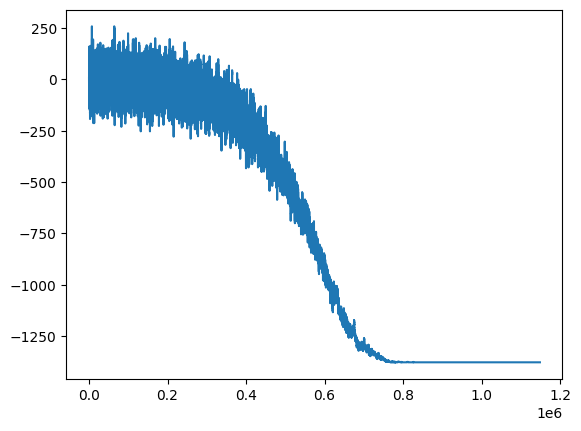

In [12]:
import matplotlib.pyplot as plt
plt.plot(energy_data)

Initializing Photonic Annealer...
Connecting to hardware...
SLM connected. Resolution: 1920 x 1080
Serial port COM21 opened at 115200 baud (timeout=0.001).
Preparing model (layout, compensation, eigendecomposition)...
  - SLM Layout: 40 rows x 20 cols
  - Macropixel Size: 96 x 27 pixels
[perf] Precomputed alpha matrix (800x800)
Preparation complete.
Evaluating initial random spin configuration...
Initial energy: 18.5813 (eval time: 35.90s)

Current Temperature: 1.0000
  Step 2/15 | New Energy Accepted: 6.8427
  Step 4/15 | New Energy Accepted: -12.8366
  Step 6/15 | New Energy Accepted: -19.0685
  Temp step took 430.13s

Current Temperature: 0.9500
  Step 8/15 | New Energy Accepted: -39.8423
  Temp step took 397.62s

Current Temperature: 0.9025
  Temp step took 408.80s

Current Temperature: 0.8574
  Temp step took 414.72s

Current Temperature: 0.8145
  Temp step took 442.44s

Current Temperature: 0.7738
  Temp step took 413.10s

Current Temperature: 0.7351
  Temp step took 407.02s

Cur

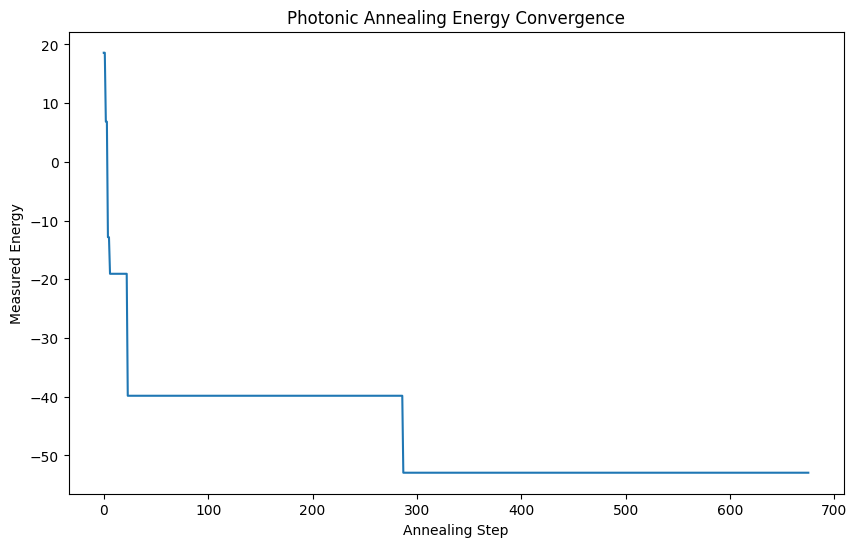

In [14]:
Gset_800 = PhotonicAnnealer(-1*matrix, 1000, 1000)

# --- 3. Define Annealing Parameters ---
INITIAL_TEMP = 1.0
FINAL_TEMP = 0.1
COOLING_RATE = 0.95
STEPS_PER_TEMP = 15 # Set low for testing, increase for real runs

import logging


final_spins, energy_data = Gset_800.run_annealing(
            initial_temp=INITIAL_TEMP,
            final_temp=FINAL_TEMP,
            cooling_rate=COOLING_RATE,
            steps_per_temp=STEPS_PER_TEMP
        )


In [15]:
import time
# print(energy_data)
copy_energy_data = energy_data.copy()

diction = {'energy': copy_energy_data,
           'spins': final_spins
           }

name = str(time.time())

np.savez(f"gsetdata_g17_{name}.npz", **diction)
# for i in range(len(energy_data)):
#     if i == len(energy_data) - 1:
#         break
#     if energy_data[i] < energy_data[i+1]:
#         energy_data[i+1] = energy_data[i]

# import matplotlib.pyplot as plt
# plt.plot(energy_data)

def get_cut_value(adj_matrix, spins):
    """
    Calculates the value of a cut given an adjacency matrix and spin assignments.

    The cut value is the sum of weights of all edges that cross the partition.
    An edge (i, j) crosses the partition if node i and node j have different spins.

    Args:
        adj_matrix (list[list[float]] or np.ndarray): 
            A 2D list or NumPy array representing the weighted adjacency matrix 
            of the graph. adj_matrix[i][j] is the weight of the edge between 
            node i and node j. Assumed to be symmetric.
        
        spins (list[int] or np.ndarray): 
            A 1D list or array of spin assignments for each node.
            Typically +1 or -1, where +1 represents one partition and -1 
            represents the other. Must be the same length as the number of nodes.

    Returns:
        float: The total weight of the edges crossing the cut.
        
    Raises:
        ValueError: If the dimensions of the matrix and spin vector do not match.
    """
    
    num_nodes = len(adj_matrix)
    
    # --- Input Validation ---
    if num_nodes == 0:
        return 0
    if num_nodes != len(adj_matrix[0]):
        raise ValueError("Adjacency matrix must be square.")
    if num_nodes != len(spins):
        raise ValueError(f"Spin list length ({len(spins)}) must match the "
                         f"number of nodes ({num_nodes}).")

    cut_value = 0.0

    # Iterate over the upper triangle of the adjacency matrix
    # This ensures we count each edge (i, j) only once
    for i in range(num_nodes):
        for j in range(i + 1, num_nodes):
            
            edge_weight = adj_matrix[i][j]
            
            # Check if an edge exists
            if edge_weight > 0:
                # Check if the nodes are in different partitions (spins are different)
                if spins[i] != spins[j]:
                    # If they are, this edge crosses the cut. Add its weight.
                    cut_value += edge_weight
                    
    return cut_value
cut_value = get_cut_value(matrix, final_spins)
print(cut_value)

2338.0


In [25]:
Gset_800.disconnect_hardware()

Serial port COM21 closed.


In [27]:
Gset_800 = PhotonicAnnealer(matrix, 1000, 1000)

Gset_800.beam_sigma_x = 350
Gset_800.beam_sigma_y = 350

# --- 3. Define Annealing Parameters ---
INITIAL_TEMP = 5
FINAL_TEMP = 3
COOLING_RATE = 0.90
STEPS_PER_TEMP = 100 # Set low for testing, increase for real runs

import logging


final_spins, energy_data = Gset_800.run_annealing(
            initial_temp=INITIAL_TEMP,
            final_temp=FINAL_TEMP,
            cooling_rate=COOLING_RATE,
            steps_per_temp=STEPS_PER_TEMP
        )


Initializing Photonic Annealer...
Connecting to hardware...
SLM connected. Resolution: 1920 x 1080


RuntimeError: Failed to connect to serial port COM21 at 115200 baud: could not open port 'COM21': PermissionError(13, 'Access is denied.', None, 5)

In [13]:
import time
# print(energy_data)
copy_energy_data = energy_data.copy()

diction = {'energy': copy_energy_data,
           'spins': final_spins
           }

name = str(time.time())

np.savez(f"gsetdatag17_comp_{name}.npz", **diction)
for i in range(len(energy_data)):
    if i == len(energy_data) - 1:
        break
    if energy_data[i] < energy_data[i+1]:
        energy_data[i+1] = energy_data[i]

import matplotlib.pyplot as plt
plt.plot(energy_data)

def get_cut_value(adj_matrix, spins):
    """
    Calculates the value of a cut given an adjacency matrix and spin assignments.

    The cut value is the sum of weights of all edges that cross the partition.
    An edge (i, j) crosses the partition if node i and node j have different spins.

    Args:
        adj_matrix (list[list[float]] or np.ndarray): 
            A 2D list or NumPy array representing the weighted adjacency matrix 
            of the graph. adj_matrix[i][j] is the weight of the edge between 
            node i and node j. Assumed to be symmetric.
        
        spins (list[int] or np.ndarray): 
            A 1D list or array of spin assignments for each node.
            Typically +1 or -1, where +1 represents one partition and -1 
            represents the other. Must be the same length as the number of nodes.

    Returns:
        float: The total weight of the edges crossing the cut.
        
    Raises:
        ValueError: If the dimensions of the matrix and spin vector do not match.
    """
    
    num_nodes = len(adj_matrix)
    
    # --- Input Validation ---
    if num_nodes == 0:
        return 0
    if num_nodes != len(adj_matrix[0]):
        raise ValueError("Adjacency matrix must be square.")
    if num_nodes != len(spins):
        raise ValueError(f"Spin list length ({len(spins)}) must match the "
                         f"number of nodes ({num_nodes}).")

    cut_value = 0.0

    # Iterate over the upper triangle of the adjacency matrix
    # This ensures we count each edge (i, j) only once
    for i in range(num_nodes):
        for j in range(i + 1, num_nodes):
            
            edge_weight = adj_matrix[i][j]
            
            # Check if an edge exists
            if True:
                # Check if the nodes are in different partitions (spins are different)
                if spins[i] != spins[j]:
                    # If they are, this edge crosses the cut. Add its weight.
                    cut_value += edge_weight
                    
    return cut_value
cut_value = get_cut_value(matrix, final_spins)
print(cut_value)

NameError: name 'energy_data' is not defined

In [ ]:

# --- 3. Define Annealing Parameters ---
INITIAL_TEMP = 100
FINAL_TEMP = 3
COOLING_RATE = 0.95
STEPS_PER_TEMP = 15 # Set low for testing, increase for real runs

import logging


final_spins, energy_data = Gset_800.run_annealing(
            initial_temp=INITIAL_TEMP,
            final_temp=FINAL_TEMP,
            cooling_rate=COOLING_RATE,
            steps_per_temp=STEPS_PER_TEMP
        )
import time
print(energy_data)
copy_energy_data = energy_data.copy()

diction = {'energy': copy_energy_data,
           'spins': final_spins
           }

name = str(time.time())

np.savez(f"gsetdata_comp_{name}.npz", **diction)
for i in range(len(energy_data)):
    if i == len(energy_data) - 1:
        break
    if energy_data[i] < energy_data[i+1]:
        energy_data[i+1] = energy_data[i]

import matplotlib.pyplot as plt
plt.plot(energy_data)

def get_cut_value(adj_matrix, spins):
    """
    Calculates the value of a cut given an adjacency matrix and spin assignments.

    The cut value is the sum of weights of all edges that cross the partition.
    An edge (i, j) crosses the partition if node i and node j have different spins.

    Args:
        adj_matrix (list[list[float]] or np.ndarray): 
            A 2D list or NumPy array representing the weighted adjacency matrix 
            of the graph. adj_matrix[i][j] is the weight of the edge between 
            node i and node j. Assumed to be symmetric.
        
        spins (list[int] or np.ndarray): 
            A 1D list or array of spin assignments for each node.
            Typically +1 or -1, where +1 represents one partition and -1 
            represents the other. Must be the same length as the number of nodes.

    Returns:
        float: The total weight of the edges crossing the cut.
        
    Raises:
        ValueError: If the dimensions of the matrix and spin vector do not match.
    """
    
    num_nodes = len(adj_matrix)
    
    # --- Input Validation ---
    if num_nodes == 0:
        return 0
    if num_nodes != len(adj_matrix[0]):
        raise ValueError("Adjacency matrix must be square.")
    if num_nodes != len(spins):
        raise ValueError(f"Spin list length ({len(spins)}) must match the "
                         f"number of nodes ({num_nodes}).")

    cut_value = 0.0

    # Iterate over the upper triangle of the adjacency matrix
    # This ensures we count each edge (i, j) only once
    for i in range(num_nodes):
        for j in range(i + 1, num_nodes):
            
            edge_weight = adj_matrix[i][j]
            
            # Check if an edge exists
            if True:
                # Check if the nodes are in different partitions (spins are different)
                if spins[i] != spins[j]:
                    # If they are, this edge crosses the cut. Add its weight.
                    cut_value += edge_weight
                    
    return cut_value
cut_value = get_cut_value(matrix, final_spins)
print(cut_value)

Evaluating initial random spin configuration...
Initial energy: -0.6584 (eval time: 20.00s)

Current Temperature: 10.0000
  Step 1/10 | New Energy Accepted: -1.7642
  Step 2/10 | New Energy Accepted: 1.0455
  Step 3/10 | New Energy Accepted: -2.8630
  Step 4/10 | New Energy Accepted: 0.8460
  Step 5/10 | New Energy Accepted: -3.9036
  Step 6/10 | New Energy Accepted: 1.4339
  Step 7/10 | New Energy Accepted: 2.1703
  Step 8/10 | New Energy Accepted: 0.4530
  Step 9/10 | New Energy Accepted: 0.5095
  Step 10/10 | New Energy Accepted: 0.0416
  Temp step took 188.68s

Current Temperature: 9.5000
  Step 2/10 | New Energy Accepted: -2.3468
  Step 4/10 | New Energy Accepted: -2.3732
  Step 5/10 | New Energy Accepted: -1.2643
  Step 7/10 | New Energy Accepted: -0.4001
  Step 8/10 | New Energy Accepted: -1.4111
  Step 9/10 | New Energy Accepted: -2.2863
  Step 10/10 | New Energy Accepted: -0.8040
  Temp step took 183.13s

Current Temperature: 9.0250
  Step 1/10 | New Energy Accepted: 0.6882
  

In [2]:
import numpy as np

def generate_npp_problem(size, min_val=1, max_val=50, seed=None):
    """
    Generates a random Number Partitioning problem and its Ising Matrix.
    
    Args:
        size (int): Number of items to partition.
        min_val (int): Minimum value of a number in the set.
        max_val (int): Maximum value of a number in the set.
        seed (int): Random seed for reproducibility.
        
    Returns:
        J (np.array): The Ising coupling matrix (fully connected).
        numbers (np.array): The actual values (needed for decoding later).
    """
    if seed is not None:
        np.random.seed(seed)
        
    # 1. Generate random numbers
    numbers = np.random.randint(min_val, max_val + 1, size)
    
    # 2. Construct Ising Matrix J
    # Formula: J_ij = - (n_i * n_j)
    # We use negative product because MaxCut solvers try to prevent
    # connected nodes from having the same spin. 
    # Here, larger products = stronger 'repulsion' between numbers.
    J = -1 * np.outer(numbers, numbers)
    
    # 3. Zero out the diagonal (No self-interaction)
    np.fill_diagonal(J, 0)
    
    return J, numbers

In [3]:
def decode_npp(spins, numbers):
    """
    Decodes the spin configuration back into two number sets.
    
    Args:
        spins (array-like): Vector of -1 and +1 from your solver.
        numbers (array-like): The original list of numbers from the generator.
        
    Returns:
        dict: Contains the two sets, their sums, and the difference.
    """
    set_A = []
    set_B = []
    
    # Map spins to sets
    # Spin +1 -> Set A
    # Spin -1 -> Set B
    for i, s in enumerate(spins):
        if s > 0:
            set_A.append(numbers[i])
        else:
            set_B.append(numbers[i])
            
    sum_A = sum(set_A)
    sum_B = sum(set_B)
    diff = abs(sum_A - sum_B)
    
    return {
        "set_A": set_A,
        "set_B": set_B,
        "sum_A": sum_A,
        "sum_B": sum_B,
        "diff": diff,
        "is_perfect": diff == 0
    }

In [4]:
matrix, numbers = generate_npp_problem(size=200, min_val=1, max_val=50, seed=42)

In [5]:
import numpy as np
import heapq
import bisect
import itertools
from typing import List, Tuple, Dict, Optional

def generate_npp_weights(
    n: int,
    kind: str = "int_uniform",
    low: int = 1,
    high: int = 10**6,
    mean: float = 1.0,
    scale: float = 1.0,
    distribution: str = "uniform",
    seed: Optional[int] = None
) -> np.ndarray:
    """
    Generate an NPP weights vector of length n.

    Args:
        n: number of weights to generate.
        kind: one of
            - "int_uniform" (default): integers in [low, high]
            - "float_uniform": floats in [low, high)
            - "normal": Gaussian with mean, scale (std)
            - "exp": exponential distribution with scale (mean)
            - "power_law": Pareto-like (heavy tail) using 'scale' (alpha)
            - "sorted_hard": generate a harder instance: many small + a few very large (mixed)
        low, high: used for uniform variants (ints/floats).
        mean, scale: used for normal/exp/power_law.
        distribution: alias for kind (kept for backward compatibility).
        seed: optional random seed for reproducibility.

    Returns:
        numpy.ndarray of dtype float64, shape (n,).
    """
    if seed is not None:
        np.random.seed(seed)

    if distribution != "uniform":
        # support both names
        kind = distribution

    if kind == "int_uniform":
        w = np.random.randint(low, high + 1, size=n).astype(np.float64)
    elif kind == "float_uniform":
        w = np.random.random(size=n) * (high - low) + low
    elif kind == "normal":
        w = np.random.normal(loc=mean, scale=scale, size=n).astype(np.float64)
        # ensure positives (NPP weights are typically positive)
        w = np.abs(w)
    elif kind == "exp":
        w = np.random.exponential(scale=scale, size=n).astype(np.float64)
    elif kind == "power_law":
        # simple Pareto-ish: X = scale * (1 + U) ** (-1/alpha) but numpy has pareto
        alpha = max(0.1, scale)  # treat scale param as alpha if >0
        w = (np.random.pareto(alpha, size=n) + 1.0) * mean
    elif kind == "sorted_hard":
        # mix many small numbers and a few very large numbers -> often harder
        small_count = max(1, int(0.75 * n))
        large_count = n - small_count
        small = np.random.randint(low, min(high, 1000) + 1, size=small_count).astype(np.float64)
        large = np.random.randint(max(1000, low), high + 1, size=large_count).astype(np.float64)
        w = np.concatenate([small, large])
        np.random.shuffle(w)
    else:
        raise ValueError(f"Unknown kind/distribution: {kind}")

    return w.astype(np.float64)


# -------------------------
# Helpers for verification
# -------------------------
def _theoretical_energy(weights: np.ndarray, spins: np.ndarray) -> float:
    """Compute E = (w^T s)^2 (the NPP energy)."""
    w = np.asarray(weights, dtype=np.float64).flatten()
    s = np.asarray(spins, dtype=np.int8).flatten()
    dot = float(np.dot(w, s))
    return dot * dot

def _partition_imbalance(weights: np.ndarray, spins: np.ndarray) -> float:
    """Return absolute difference between subset sums: |sum_{s=+1} w - sum_{s=-1} w|."""
    w = np.asarray(weights, dtype=np.float64).flatten()
    s = np.asarray(spins, dtype=np.int8).flatten()
    sum_plus = float(np.sum(w[s == 1])) if np.any(s == 1) else 0.0
    sum_minus = float(np.sum(w[s == -1])) if np.any(s == -1) else 0.0
    return abs(sum_plus - sum_minus)


def _kk_heuristic_optimal_diff(weights: np.ndarray) -> float:
    """
    Karmarkar-Karp heuristic (greedy differencing) - fast approximate solution.
    Returns the minimal difference (|sumA - sumB|) produced by the heuristic.
    """
    # Use a max-heap (negate values for Python's min-heap)
    heap = [-float(x) for x in weights]
    heapq.heapify(heap)
    while len(heap) > 1:
        a = -heapq.heappop(heap)
        b = -heapq.heappop(heap)
        diff = abs(a - b)
        heapq.heappush(heap, -diff)
    return float(-heap[0]) if heap else 0.0


def _meet_in_the_middle_optimal(weights: np.ndarray) -> Tuple[float, Optional[Tuple[List[int], List[int]]]]:
    """
    Meet-in-the-middle exact/near-exact optimal partition difference.
    Returns (min_diff, (subsetA_indices, subsetB_indices)) if n <= 40 (attempts to reconstruct a partition),
    otherwise raises ValueError.
    Complexity: O(2^{n/2}) memory/time.
    """
    w = np.asarray(weights, dtype=np.float64).flatten()
    n = len(w)
    if n == 0:
        return 0.0, ([], [])
    if n > 40:
        raise ValueError("Meet-in-the-middle is feasible for n <= ~40 only. Use KK heuristic for larger n.")

    half = n // 2
    left = w[:half]
    right = w[half:]

    # compute all subset sums for left and right with indices bitmask
    left_sums = []
    for mask in range(1 << len(left)):
        s = 0.0
        idxs = []
        for j in range(len(left)):
            if (mask >> j) & 1:
                s += left[j]
                idxs.append(j)
        left_sums.append((s, mask, idxs))
    right_sums = []
    for mask in range(1 << len(right)):
        s = 0.0
        idxs = []
        for j in range(len(right)):
            if (mask >> j) & 1:
                s += right[j]
                idxs.append(half + j)
        right_sums.append((s, mask, idxs))

    # Sort right_sums by sum to binary search
    right_sums.sort(key=lambda x: x[0])
    right_vals = [r[0] for r in right_sums]

    total = float(np.sum(w))
    target = total / 2.0

    best_diff = float('inf')
    best_choice = None

    # For each left sum, find best right sum to approach target
    for ls, lmask, lidxs in left_sums:
        rem = target - ls
        # find insertion point
        i = bisect.bisect_left(right_vals, rem)
        # consider i and i-1
        for j in (i, i - 1):
            if 0 <= j < len(right_sums):
                rs, rmask, ridxs = right_sums[j]
                sumA = ls + rs
                sumB = total - sumA
                diff = abs(sumA - sumB)
                if diff < best_diff:
                    best_diff = diff
                    subsetA_idxs = lidxs + ridxs
                    subsetB_idxs = [i for i in range(n) if i not in subsetA_idxs]
                    best_choice = (subsetA_idxs, subsetB_idxs)
                    if best_diff == 0:
                        return 0.0, best_choice

    return float(best_diff), best_choice


def verify_npp_solution(weights: np.ndarray,
                        spins: np.ndarray,
                        do_optimal: bool = True,
                        optimal_method_threshold: int = 40,
                        return_partition: bool = False) -> Dict:
    """
    Verify a proposed solution (spin assignment) for NPP.

    Args:
        weights: 1D array-like of weights (positive floats)
        spins: 1D array-like with values +1 or -1 (same length as weights)
        do_optimal: if True, attempt to compute or approximate optimal partition difference.
        optimal_method_threshold: if n <= this threshold, attempt meet-in-the-middle exact; else use KK heuristic.
        return_partition: if True and exact solution found, returns indices of subsets.

    Returns:
        dict with keys:
          - 'n' : number of items
          - 'measured_energy' : E(s) = (w^T s)^2
          - 'imbalance' : |sum_{+1} w - sum_{-1} w|
          - 'theoretical_energy' : same as measured_energy (alias)
          - 'optimal_diff' : best achievable difference (if computed; else None)
          - 'optimal_energy' : (optimal_diff)**2 (if computed)
          - 'relative_gap' : (measured - optimal)/max(1, optimal) (if optimal known)
          - 'status' : 'ok' or 'optimal_found' or 'approximate'
          - 'partition' : optional (subsetA_indices, subsetB_indices) if requested and found
    """
    w = np.asarray(weights, dtype=np.float64).flatten()
    s = np.asarray(spins, dtype=np.int8).flatten()
    n = len(w)
    if n == 0:
        return {
            'n': 0,
            'measured_energy': 0.0,
            'imbalance': 0.0,
            'theoretical_energy': 0.0,
            'optimal_diff': 0.0,
            'optimal_energy': 0.0,
            'relative_gap': 0.0,
            'status': 'trivial',
            'partition': ([], [])
        }

    if s.shape[0] != n:
        raise ValueError("spins length must equal weights length")

    # compute current metrics
    measured_energy = _theoretical_energy(w, s)
    imbalance = _partition_imbalance(w, s)

    result = {
        'n': n,
        'measured_energy': measured_energy,
        'theoretical_energy': measured_energy,
        'imbalance': imbalance,
        'optimal_diff': None,
        'optimal_energy': None,
        'relative_gap': None,
        'status': None,
        'partition': None
    }

    if not do_optimal:
        result['status'] = 'no_optimal_checked'
        return result

    # Decide method
    if n <= optimal_method_threshold and n <= 40:
        # exact via meet-in-the-middle (safe up to ~40)
        try:
            opt_diff, partition = _meet_in_the_middle_optimal(w)
            result['optimal_diff'] = opt_diff
            result['optimal_energy'] = opt_diff * opt_diff
            result['relative_gap'] = (measured_energy - result['optimal_energy']) / max(1e-12, result['optimal_energy'])
            result['status'] = 'optimal_found'
            if return_partition and partition is not None:
                result['partition'] = partition
        except Exception as e:
            # fallback to KK
            kk_diff = _kk_heuristic_optimal_diff(w)
            result['optimal_diff'] = kk_diff
            result['optimal_energy'] = kk_diff * kk_diff
            result['relative_gap'] = (measured_energy - result['optimal_energy']) / max(1e-12, result['optimal_energy'])
            result['status'] = 'approximate_kk'
    else:
        # use Karmarkar-Karp heuristic for larger n
        kk_diff = _kk_heuristic_optimal_diff(w)
        result['optimal_diff'] = kk_diff
        result['optimal_energy'] = kk_diff * kk_diff
        result['relative_gap'] = (measured_energy - result['optimal_energy']) / max(1e-12, result['optimal_energy'])
        result['status'] = 'approximate_kk'

    return result


In [6]:
weights = generate_npp_weights(100, kind="int_uniform", low=1, high=10, seed=123)

In [9]:
npp_solver = NumberPartitioningAnnealer(weights, 350, 350)

Initializing Number Partitioning Annealer...
Initializing Photonic Annealer Base...
Connecting to hardware...
SLM connected. Resolution: 1920 x 1080
Serial port COM21 opened at 115200 baud.
Photodiode reader thread started.
Base annealer initialized.
Preparing model for 100 spins...
  - SLM Layout: 5 rows x 20 cols
  - Macropixel Size: 96 x 216 pixels
  - (NPP) Performing rank-1 eigendecomposition...
  - Identified 1 active eigenmodes.
  - Precomputed alpha matrix ((100, 1)).
Preparation complete.


Running Batched NPP Annealing (batch_size=1)...
Initial measured energy: 2.627106 (eval time: 0.04s)

Temperature: 1.000000
  Step 1: Accepted energy 2.828571 (idx flipped: 7)
  Step 201: Accepted energy 2.664176 (idx flipped: 83)
  Temp iteration time: 33.88s

Batched NPP annealing finished.
Total elapsed time: 33.88s
Best measured energy found: 1.950989
Best spin vector sum (partition diff): -20.0000
Best theoretical energy (sum^2): 400.0000


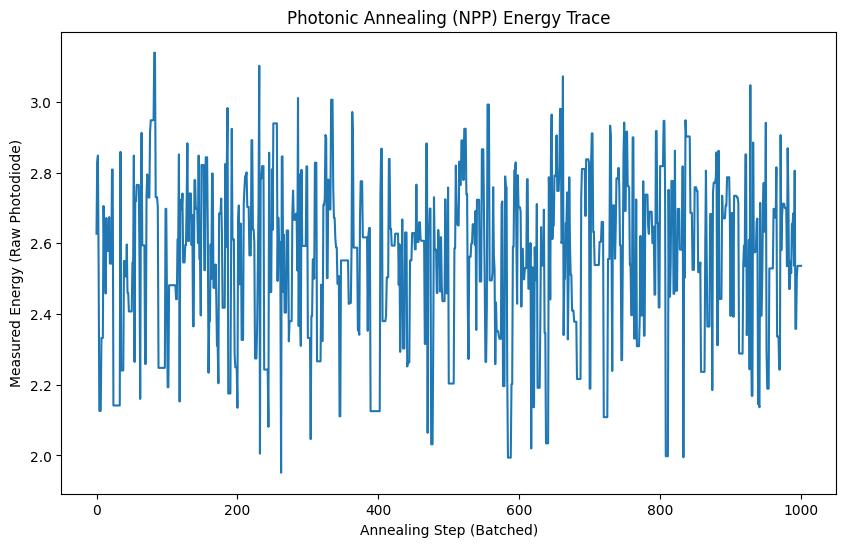

(array([ 1,  1,  1, -1,  1, -1,  1, -1,  1, -1,  1,  1, -1, -1,  1, -1,  1,
        -1, -1, -1, -1, -1, -1, -1,  1,  1, -1, -1,  1,  1,  1,  1,  1, -1,
         1,  1,  1, -1,  1,  1,  1, -1, -1, -1,  1,  1, -1, -1,  1,  1,  1,
        -1,  1, -1,  1, -1, -1, -1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,
        -1,  1, -1, -1,  1,  1,  1,  1, -1, -1,  1, -1,  1,  1,  1, -1, -1,
        -1,  1, -1, -1,  1,  1,  1, -1,  1, -1, -1,  1,  1, -1, -1]),
 1.950989010989011)

In [12]:
INITIAL_TEMP = 1
FINAL_TEMP = 0.8
COOLING_RATE = 0.8
STEPS_PER_TEMP = 1000




npp_solver.run_annealing(
            initial_temp=INITIAL_TEMP,
            final_temp=FINAL_TEMP,
            cooling_rate=COOLING_RATE,
            steps_per_temp=STEPS_PER_TEMP,
            batch_size=1
)

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import math
import random

def generate_npp_weights(size, min_val=1, max_val=100):
    """
    Generates a list of random integer weights for the Number Partitioning Problem.

    Args:
        size (int): The number of weights to generate (n).
        min_val (int): The minimum value for a weight.
        max_val (int): The maximum value for a weight.

    Returns:
        np.ndarray: A NumPy array of 'size' random integer weights.
    """
    weights = np.random.randint(min_val, max_val + 1, size=size)
    print(f"Generated {size} weights with a total sum of {np.sum(weights)}")
    return weights

def run_sa_for_npp(weights, initial_temp=10.0, cooling_rate=0.995, max_steps=10000):
    """
    Performs Simulated Annealing (SA) to solve the Number Partitioning Problem.

    The goal is to find a spin vector 's' (of -1s and 1s) that
    minimizes the energy H = (sum(weights * s))^2.

    Args:
        weights (np.ndarray): The list of weights to partition.
        initial_temp (float): The starting temperature for annealing.
        cooling_rate (float): The multiplicative cooling factor (e.g., 0.99).
        max_steps (int): The total number of annealing steps.

    Returns:
        tuple: (final_spin_vector, final_dot_product)
               - final_spin_vector (np.ndarray): The best spin vector found.
               - final_dot_product (float): The final sum(weights * s).
                 The absolute value of this is the partition difference.
    """
    
    n = len(weights)
    
    # 1. Initialize a random spin vector
    current_spins = np.random.choice([-1, 1], size=n)
    
    # 2. Calculate the initial energy
    # We track the dot product (partition sum) directly
    current_dot_product = np.dot(weights, current_spins)
    current_energy = current_dot_product**2
    
    # Keep track of the best solution found so far
    best_spins = np.copy(current_spins)
    best_energy = current_energy
    best_dot_product = current_dot_product
    
    temp = initial_temp

    energies = []
    
    # 3. Start the annealing loop
    for step in range(max_steps):
        # 4. Pick a random spin to flip
        flip_index = random.randint(0, n - 1)
        
        # 5. Calculate the *new* energy if we flip this spin
        # This is an efficient way to calculate the change
        # S_new = S_current - 2 * w_i * s_i
        new_dot_product = current_dot_product - 2 * weights[flip_index] * current_spins[flip_index]
        new_energy = new_dot_product**2
        # energies.append(new_energy)
        
        # Calculate energy difference
        delta_energy = new_energy - current_energy
        
        # 6. Decide whether to accept the move
        if delta_energy < 0:
            # Always accept a better solution
            accept_move = True
        else:
            # Accept a worse solution with some probability
            acceptance_prob = math.exp(-delta_energy / temp)
            accept_move = random.random() < acceptance_prob
            
        if accept_move:
            # Update the current state
            current_spins[flip_index] *= -1
            current_energy = new_energy
            energies.append(current_energy)
            current_dot_product = new_dot_product
            
            # Check if this is the new best solution
            if current_energy < best_energy:
                best_energy = current_energy
                best_spins = np.copy(current_spins)
                best_dot_product = current_dot_product
                
        # 7. Cool the temperature
        temp *= cooling_rate

    plt.plot(energies)
    plt.xlabel('Step')
    plt.ylabel('Energy')
    plt.title('Energy vs. Annealing Step')
    plt.show()
        
    # Return the best solution found during the entire run
    return best_spins, best_dot_product

In [8]:
weights = generate_npp_weights(size=100)

Generated 100 weights with a total sum of 5134


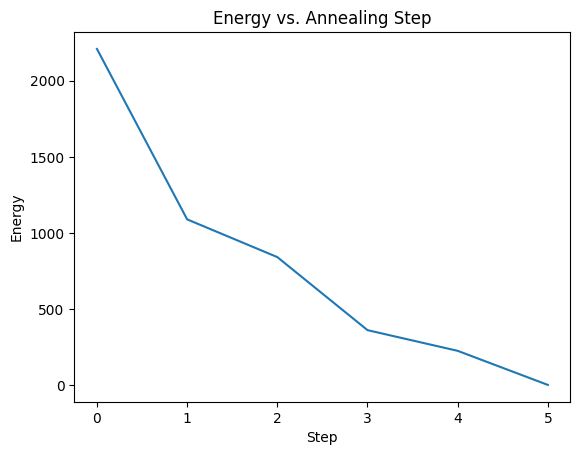

1


In [4]:
final_spins, final_dot_product = run_sa_for_npp(weights, initial_temp=10.0, cooling_rate=0.995, max_steps=10000)

print(final_dot_product)

Running Batched NPP Annealing (batch_size=1)...
Initial measured energy: 2.446593 (eval time: 0.04s)

Temperature: 10.000000
  Step 21: Accepted energy 2.472381 (idx flipped: 79)
  Step 41: Accepted energy 2.556190 (idx flipped: 19)
  Step 81: Accepted energy 2.793114 (idx flipped: 61)
  Temp iteration time: 3.66s

Temperature: 9.500000
  Step 1: Accepted energy 2.228205 (idx flipped: 4)
  Step 21: Accepted energy 2.738315 (idx flipped: 91)
  Step 61: Accepted energy 2.677070 (idx flipped: 15)
  Step 81: Accepted energy 2.762491 (idx flipped: 48)
  Temp iteration time: 3.39s

Temperature: 9.025000
  Step 1: Accepted energy 2.872088 (idx flipped: 95)
  Step 41: Accepted energy 2.424835 (idx flipped: 68)
  Step 61: Accepted energy 2.620659 (idx flipped: 73)
  Step 81: Accepted energy 2.154066 (idx flipped: 59)
  Temp iteration time: 3.56s

Temperature: 8.573750
  Step 21: Accepted energy 2.541685 (idx flipped: 40)
  Step 81: Accepted energy 2.837436 (idx flipped: 36)
  Temp iteration tim

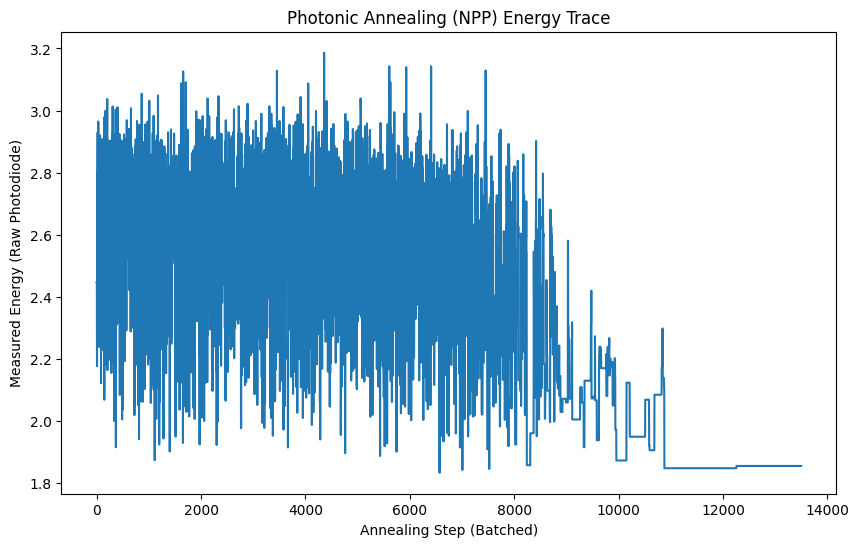

(array([ 1, -1,  1, -1,  1, -1, -1, -1,  1, -1,  1,  1,  1,  1,  1,  1,  1,
        -1,  1,  1,  1,  1,  1, -1, -1,  1, -1,  1, -1,  1,  1,  1, -1, -1,
         1, -1,  1, -1,  1, -1,  1, -1, -1, -1, -1, -1,  1, -1, -1, -1,  1,
        -1, -1, -1,  1, -1,  1, -1, -1,  1, -1,  1,  1,  1,  1, -1,  1, -1,
        -1, -1, -1, -1, -1,  1, -1, -1, -1, -1, -1,  1, -1,  1, -1, -1,  1,
         1, -1,  1,  1, -1, -1, -1, -1,  1, -1, -1,  1,  1,  1, -1]),
 1.8325274725274725)

In [9]:
INITIAL_TEMP = 10.0
FINAL_TEMP = 0.01
COOLING_RATE = 0.95
STEPS_PER_TEMP = 100




npp_solver.run_annealing(
            initial_temp=INITIAL_TEMP,
            final_temp=FINAL_TEMP,
            cooling_rate=COOLING_RATE,
            steps_per_temp=STEPS_PER_TEMP,
            batch_size=1
)

# NPP Benchmars and sims using dynamic cluster algorithm

In [2]:
import numpy as np
import heapq
import bisect
import itertools
from typing import List, Tuple, Dict, Optional

def generate_npp_weights(
    n: int,
    kind: str = "int_uniform",
    low: int = 1,
    high: int = 10**6,
    mean: float = 1.0,
    scale: float = 1.0,
    distribution: str = "uniform",
    seed: Optional[int] = None
) -> np.ndarray:
    """
    Generate an NPP weights vector of length n.

    Args:
        n: number of weights to generate.
        kind: one of
            - "int_uniform" (default): integers in [low, high]
            - "float_uniform": floats in [low, high)
            - "normal": Gaussian with mean, scale (std)
            - "exp": exponential distribution with scale (mean)
            - "power_law": Pareto-like (heavy tail) using 'scale' (alpha)
            - "sorted_hard": generate a harder instance: many small + a few very large (mixed)
        low, high: used for uniform variants (ints/floats).
        mean, scale: used for normal/exp/power_law.
        distribution: alias for kind (kept for backward compatibility).
        seed: optional random seed for reproducibility.

    Returns:
        numpy.ndarray of dtype float64, shape (n,).
    """
    if seed is not None:
        np.random.seed(seed)

    if distribution != "uniform":
        # support both names
        kind = distribution

    if kind == "int_uniform":
        w = np.random.randint(low, high + 1, size=n).astype(np.float64)
    elif kind == "float_uniform":
        w = np.random.random(size=n) * (high - low) + low
    elif kind == "normal":
        w = np.random.normal(loc=mean, scale=scale, size=n).astype(np.float64)
        # ensure positives (NPP weights are typically positive)
        w = np.abs(w)
    elif kind == "exp":
        w = np.random.exponential(scale=scale, size=n).astype(np.float64)
    elif kind == "power_law":
        # simple Pareto-ish: X = scale * (1 + U) ** (-1/alpha) but numpy has pareto
        alpha = max(0.1, scale)  # treat scale param as alpha if >0
        w = (np.random.pareto(alpha, size=n) + 1.0) * mean
    elif kind == "sorted_hard":
        # mix many small numbers and a few very large numbers -> often harder
        small_count = max(1, int(0.75 * n))
        large_count = n - small_count
        small = np.random.randint(low, min(high, 1000) + 1, size=small_count).astype(np.float64)
        large = np.random.randint(max(1000, low), high + 1, size=large_count).astype(np.float64)
        w = np.concatenate([small, large])
        np.random.shuffle(w)
    else:
        raise ValueError(f"Unknown kind/distribution: {kind}")

    return w.astype(np.float64)


# -------------------------
# Helpers for verification
# -------------------------
def _theoretical_energy(weights: np.ndarray, spins: np.ndarray) -> float:
    """Compute E = (w^T s)^2 (the NPP energy)."""
    w = np.asarray(weights, dtype=np.float64).flatten()
    s = np.asarray(spins, dtype=np.int8).flatten()
    dot = float(np.dot(w, s))
    return dot * dot

def _partition_imbalance(weights: np.ndarray, spins: np.ndarray) -> float:
    """Return absolute difference between subset sums: |sum_{s=+1} w - sum_{s=-1} w|."""
    w = np.asarray(weights, dtype=np.float64).flatten()
    s = np.asarray(spins, dtype=np.int8).flatten()
    sum_plus = float(np.sum(w[s == 1])) if np.any(s == 1) else 0.0
    sum_minus = float(np.sum(w[s == -1])) if np.any(s == -1) else 0.0
    return abs(sum_plus - sum_minus)


def _kk_heuristic_optimal_diff(weights: np.ndarray) -> float:
    """
    Karmarkar-Karp heuristic (greedy differencing) - fast approximate solution.
    Returns the minimal difference (|sumA - sumB|) produced by the heuristic.
    """
    # Use a max-heap (negate values for Python's min-heap)
    heap = [-float(x) for x in weights]
    heapq.heapify(heap)
    while len(heap) > 1:
        a = -heapq.heappop(heap)
        b = -heapq.heappop(heap)
        diff = abs(a - b)
        heapq.heappush(heap, -diff)
    return float(-heap[0]) if heap else 0.0


def _meet_in_the_middle_optimal(weights: np.ndarray) -> Tuple[float, Optional[Tuple[List[int], List[int]]]]:
    """
    Meet-in-the-middle exact/near-exact optimal partition difference.
    Returns (min_diff, (subsetA_indices, subsetB_indices)) if n <= 40 (attempts to reconstruct a partition),
    otherwise raises ValueError.
    Complexity: O(2^{n/2}) memory/time.
    """
    w = np.asarray(weights, dtype=np.float64).flatten()
    n = len(w)
    if n == 0:
        return 0.0, ([], [])
    if n > 40:
        raise ValueError("Meet-in-the-middle is feasible for n <= ~40 only. Use KK heuristic for larger n.")

    half = n // 2
    left = w[:half]
    right = w[half:]

    # compute all subset sums for left and right with indices bitmask
    left_sums = []
    for mask in range(1 << len(left)):
        s = 0.0
        idxs = []
        for j in range(len(left)):
            if (mask >> j) & 1:
                s += left[j]
                idxs.append(j)
        left_sums.append((s, mask, idxs))
    right_sums = []
    for mask in range(1 << len(right)):
        s = 0.0
        idxs = []
        for j in range(len(right)):
            if (mask >> j) & 1:
                s += right[j]
                idxs.append(half + j)
        right_sums.append((s, mask, idxs))

    # Sort right_sums by sum to binary search
    right_sums.sort(key=lambda x: x[0])
    right_vals = [r[0] for r in right_sums]

    total = float(np.sum(w))
    target = total / 2.0

    best_diff = float('inf')
    best_choice = None

    # For each left sum, find best right sum to approach target
    for ls, lmask, lidxs in left_sums:
        rem = target - ls
        # find insertion point
        i = bisect.bisect_left(right_vals, rem)
        # consider i and i-1
        for j in (i, i - 1):
            if 0 <= j < len(right_sums):
                rs, rmask, ridxs = right_sums[j]
                sumA = ls + rs
                sumB = total - sumA
                diff = abs(sumA - sumB)
                if diff < best_diff:
                    best_diff = diff
                    subsetA_idxs = lidxs + ridxs
                    subsetB_idxs = [i for i in range(n) if i not in subsetA_idxs]
                    best_choice = (subsetA_idxs, subsetB_idxs)
                    if best_diff == 0:
                        return 0.0, best_choice

    return float(best_diff), best_choice


def verify_npp_solution(weights: np.ndarray,
                        spins: np.ndarray,
                        do_optimal: bool = True,
                        optimal_method_threshold: int = 40,
                        return_partition: bool = False) -> Dict:
    """
    Verify a proposed solution (spin assignment) for NPP.

    Args:
        weights: 1D array-like of weights (positive floats)
        spins: 1D array-like with values +1 or -1 (same length as weights)
        do_optimal: if True, attempt to compute or approximate optimal partition difference.
        optimal_method_threshold: if n <= this threshold, attempt meet-in-the-middle exact; else use KK heuristic.
        return_partition: if True and exact solution found, returns indices of subsets.

    Returns:
        dict with keys:
          - 'n' : number of items
          - 'measured_energy' : E(s) = (w^T s)^2
          - 'imbalance' : |sum_{+1} w - sum_{-1} w|
          - 'theoretical_energy' : same as measured_energy (alias)
          - 'optimal_diff' : best achievable difference (if computed; else None)
          - 'optimal_energy' : (optimal_diff)**2 (if computed)
          - 'relative_gap' : (measured - optimal)/max(1, optimal) (if optimal known)
          - 'status' : 'ok' or 'optimal_found' or 'approximate'
          - 'partition' : optional (subsetA_indices, subsetB_indices) if requested and found
    """
    w = np.asarray(weights, dtype=np.float64).flatten()
    s = np.asarray(spins, dtype=np.int8).flatten()
    n = len(w)
    if n == 0:
        return {
            'n': 0,
            'measured_energy': 0.0,
            'imbalance': 0.0,
            'theoretical_energy': 0.0,
            'optimal_diff': 0.0,
            'optimal_energy': 0.0,
            'relative_gap': 0.0,
            'status': 'trivial',
            'partition': ([], [])
        }

    if s.shape[0] != n:
        raise ValueError("spins length must equal weights length")

    # compute current metrics
    measured_energy = _theoretical_energy(w, s)
    imbalance = _partition_imbalance(w, s)

    result = {
        'n': n,
        'measured_energy': measured_energy,
        'theoretical_energy': measured_energy,
        'imbalance': imbalance,
        'optimal_diff': None,
        'optimal_energy': None,
        'relative_gap': None,
        'status': None,
        'partition': None
    }

    if not do_optimal:
        result['status'] = 'no_optimal_checked'
        return result

    # Decide method
    if n <= optimal_method_threshold and n <= 40:
        # exact via meet-in-the-middle (safe up to ~40)
        try:
            opt_diff, partition = _meet_in_the_middle_optimal(w)
            result['optimal_diff'] = opt_diff
            result['optimal_energy'] = opt_diff * opt_diff
            result['relative_gap'] = (measured_energy - result['optimal_energy']) / max(1e-12, result['optimal_energy'])
            result['status'] = 'optimal_found'
            if return_partition and partition is not None:
                result['partition'] = partition
        except Exception as e:
            # fallback to KK
            kk_diff = _kk_heuristic_optimal_diff(w)
            result['optimal_diff'] = kk_diff
            result['optimal_energy'] = kk_diff * kk_diff
            result['relative_gap'] = (measured_energy - result['optimal_energy']) / max(1e-12, result['optimal_energy'])
            result['status'] = 'approximate_kk'
    else:
        # use Karmarkar-Karp heuristic for larger n
        kk_diff = _kk_heuristic_optimal_diff(w)
        result['optimal_diff'] = kk_diff
        result['optimal_energy'] = kk_diff * kk_diff
        result['relative_gap'] = (measured_energy - result['optimal_energy']) / max(1e-12, result['optimal_energy'])
        result['status'] = 'approximate_kk'

    return result


In [3]:
generate_npp_weights(100, kind="int_uniform", low=1, high=10, seed=np.random.randint(0, 10000))

array([ 5.,  9.,  1.,  3.,  5.,  7.,  8.,  8.,  7.,  2.,  9.,  6.,  7.,
        2.,  5., 10., 10.,  4.,  5.,  5., 10., 10.,  5.,  8.,  3.,  1.,
        5.,  1.,  8., 10.,  7.,  4.,  4.,  3.,  3.,  1.,  9.,  8.,  2.,
        2., 10.,  3.,  3., 10.,  3.,  6.,  3.,  4.,  5.,  5., 10., 10.,
        2.,  7.,  2.,  7.,  6.,  7.,  2.,  5.,  2.,  9.,  3.,  9.,  9.,
        9.,  6.,  6.,  2.,  3., 10.,  3.,  8.,  1.,  7.,  2.,  8.,  7.,
        2.,  9.,  4., 10.,  7.,  6.,  8.,  7.,  6.,  1.,  8.,  6.,  4.,
        8.,  8.,  2.,  3.,  4.,  8.,  2., 10.,  8.])

Initializing Number Partitioning Annealer...
Initializing Photonic Annealer Base...
Connecting to hardware...
SLM connected. Resolution: 1920 x 1080
Serial port COM21 opened at 115200 baud.
Photodiode reader thread started.
Base annealer initialized.
Preparing model for 20 spins...
  - SLM Layout: 1 rows x 20 cols
  - Macropixel Size: 96 x 1080 pixels
  - (NPP) Performing rank-1 eigendecomposition...
  - Identified 1 active eigenmodes.
  - Precomputed alpha matrix ((20, 1)).
Preparation complete.
[iter 100] T=37.74 Nc=5 I=1 bestI=1
[iter 200] T=13.53 Nc=5 I=1 bestI=1
[iter 300] T=4.849 Nc=5 I=1 bestI=1
[iter 400] T=1.738 Nc=5 I=1 bestI=1
[iter 500] T=0.6232 Nc=5 I=1 bestI=1
[iter 600] T=0.2234 Nc=5 I=1 bestI=1
Dynamic-cluster annealing finished.
Best measured intensity: 1 after 675 iterations.


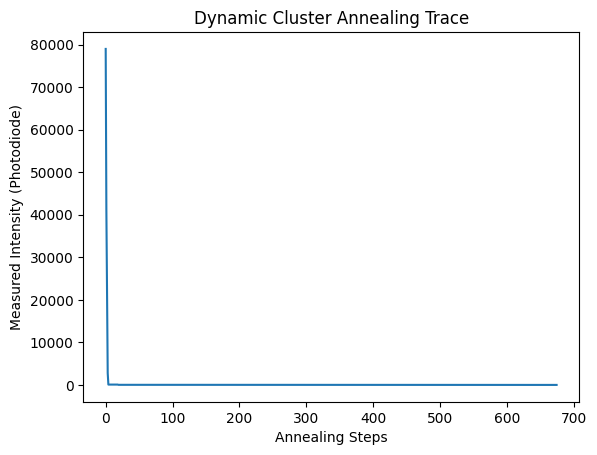

Size: 20, BeamComp: True, Imbalance: 1.0, Energy: 1.0

Disconnecting hardware...
Photodiode reader thread stopped.
Serial port COM21 closed.
SLM window closed.


AttributeError: type object 'SDK' has no attribute 'Exit'

In [ ]:
import numpy as np

sizes = [20, 40, 60, 80, 100]


INITIAL_TEMP = 100
FINAL_TEMP = 0.1
COOLING_RATE = 0.95




for size in sizes:
    weights_list = generate_npp_weights(
        n= size,
        kind= "int_uniform",
        low= 1,
        high= 100,
        seed= np.random.randint(0, 10000)
    )
    for i in range(2):


        npp_cluster_annealer = NPPDynamicClusterAnnealer(
            npp_weights= weights_list,
            beam_sigma_x= 350,
            beam_sigma_y= 350,
            Nc0=5)
        
        if i == 0:
            npp_cluster_annealer.beamcomp = False

        final_spins, final_energy, trace = npp_cluster_annealer.run_annealing(
            initial_temp=INITIAL_TEMP,
            final_temp=FINAL_TEMP,
            cooling_rate=COOLING_RATE,
            steps_per_temp= int(np.floor(size/4)),
            batch_size=1
        )

        verification = verify_npp_solution(weights_list, final_spins, do_optimal=False)
        print(f"Size: {size}, BeamComp: {i==0}, Imbalance: {verification['imbalance']}, Energy: {final_energy}")

        stats = {"final_spins": final_spins, "final_energy": final_energy, "trace": trace, "weights_list": weights_list, "verification": verification}

        np.save(f"npp_cluster_annealer_size{size}_beamcomp{i==1}.npy", stats)
        if npp_cluster_annealer != None:
            
